In [ ]:
import torch, random, numpy as np, os

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.version.cuda}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'GPU      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'Device   : {DEVICE}')

PyTorch  : 2.10.0+cu128
CUDA     : 12.8
GPU      : Tesla T4
Device   : cuda


In [ ]:
%%capture
!pip install librosa soundfile tqdm scikit-learn scipy pywavelets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

# dataset.zip → giải nén → /content/dataset/
#   /content/dataset/positive/   (CÓ còi)
#   /content/dataset/negative/   (KHÔNG có còi)
OLD_ZIP    = '/content/drive/MyDrive/dataset.zip'
OLD_DIR    = '/content/dataset'
MERGED_DIR = '/content/dataset_v4'

if not os.path.exists(OLD_DIR):
    print('Giải nén dataset.zip...')
    os.system(f'unzip -q "{OLD_ZIP}" -d /content/')
else:
    print(f'{OLD_DIR} đã tồn tại.')

# Kiểm tra cấu trúc thực tế
print('\nCấu trúc sau giải nén:')
os.system(f'find {OLD_DIR} -maxdepth 2 -type d')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Giải nén dataset.zip...

Cấu trúc sau giải nén:


256

In [ ]:
import librosa, numpy as np, pandas as pd
from pathlib import Path
from tqdm import tqdm
from scipy.signal import butter, filtfilt

# ─── Feature config (từ paper) ────────────────────────────────────────
SR         = 22050   # Tran & Tsai 2020
N_MELS     = 64      # Kong 2020 (PANNs): 64 > 32
HOP_LEN    = 512     # Tran & Tsai 2020: 23ms frame
N_FFT      = 1024
FMIN       = 300     # Apollo/Baidu 2021
FMAX       = 3500    # Tran & Tsai 2020
CLIP_SEC   = 2.0     # Tran & Tsai 2020: 1.5s optimal → 2.0s an toàn
CLIP_LEN   = int(CLIP_SEC * SR)
N_MFCC     = 40      # Tran & Tsai 2020: 40 MFCCs
STRIDE_SEC = 0.17    # Apollo/Baidu 2021: every 0.17s
PRE_EMPH   = 0.97    # Fatimah 2020

# Doppler shift range: Schroder 2013 tính ±8.7% ở 50m/s
# Ebizuka 2019: max ±8.7% (80km/h EV vs 20km/h ego)
DOPPLER_MAX_SEMITONES = 2.0  # ~8.7% freq shift ≈ 1.4 semitones, dùng 2 để an toàn

n_frames = CLIP_LEN // HOP_LEN + 1
print(f'SR={SR} | N_MELS={N_MELS} | HOP={HOP_LEN} | N_FFT={N_FFT}')
print(f'FMIN={FMIN}Hz | FMAX={FMAX}Hz  (còi VN: 500-1600Hz, QCVN)')
print(f'Clip: {CLIP_SEC}s = {CLIP_LEN} samples → {n_frames} frames')
print(f'Mel shape  : ({N_MELS}, {n_frames})')
print(f'MFCC shape : ({N_MFCC}, {n_frames})')

SR=22050 | N_MELS=64 | HOP=512 | N_FFT=1024
FMIN=300Hz | FMAX=3500Hz  (còi VN: 500-1600Hz, QCVN)
Clip: 2.0s = 44100 samples → 87 frames
Mel shape  : (64, 87)
MFCC shape : (40, 87)


In [ ]:
from scipy.signal import butter, filtfilt, chirp as scipy_chirp

# ── 1. SNR-based noise mixing (Schroder 2013) ─────────────────────────
def mix_snr(y_siren, y_noise, snr_db):
    """
    Multi-condition training: Schroder 2013 dùng SNR: clean, 20, 10, 5, 0, -5 dB.
    snr_db > 0: còi rõ hơn noise
    snr_db = 0: ngang nhau
    snr_db < 0: noise to hơn (hard case)
    """
    if len(y_noise) < len(y_siren):
        y_noise = np.tile(y_noise, int(np.ceil(len(y_siren) / len(y_noise))))
    y_noise = y_noise[:len(y_siren)]
    p_s = np.mean(y_siren ** 2) + 1e-10
    p_n = np.mean(y_noise ** 2) + 1e-10
    scale = np.sqrt(p_s / (10 ** (snr_db / 10) * p_n))
    return np.clip(y_siren + scale * y_noise, -1.0, 1.0).astype(np.float32)

# SNR levels từ Schroder 2013 multi-condition training
SNR_LEVELS = [20, 10, 5, 0, -5]  # dB

# ── 2. Doppler augmentation vật lý (Schroder 2013, Ebizuka 2019) ──────
def doppler_augment(y, sr, approach=True, speed_kmh=60):
    """
    Mô phỏng Doppler effect thực sự:
    - Khi xe tiếp cận (approach=True): freq tăng dần → giảm đột ngột khi ngang
    - Khi xe đi qua (approach=False): freq giảm dần từ đầu

    Ebizuka 2019: max EV speed 80km/h → freq shift ±8.7%
    Schroder 2013: dùng Adobe Audition với f'=f*(V±vm)/(V∓vn)

    Ở đây dùng chirp-based pitch modulation để mô phỏng sweep tần số.
    """
    V_sound = 343.0  # m/s
    v_source = speed_kmh / 3.6  # m/s

    # Tính shift factor tại điểm tiếp cận và sau khi qua
    shift_approach = V_sound / (V_sound - v_source)  # freq tăng
    shift_recede   = V_sound / (V_sound + v_source)  # freq giảm

    # Chuyển sang semitones
    def to_semitones(ratio): return 12 * np.log2(ratio)

    n = len(y)
    # Tạo envelope pitch shift thay đổi theo thời gian
    if approach:
        # Tiếp cận: pitch cao → qua điểm ngang → pitch thấp
        t_cross = 0.6  # xe ngang qua ở 60% clip
        semitones = np.where(
            np.arange(n) / n < t_cross,
            np.linspace(to_semitones(shift_approach)*0.8,
                        to_semitones(shift_approach), n)[:int(t_cross*n)],
            np.linspace(0, to_semitones(shift_recede), n - int(t_cross*n))
        )
        # Flatten do shape issues — dùng average shift
        avg_shift = np.mean([to_semitones(shift_approach), 0])
    else:
        avg_shift = to_semitones(shift_recede)

    # Clip về ±2 semitones (±8.7% theo Ebizuka 2019)
    avg_shift = np.clip(avg_shift, -DOPPLER_MAX_SEMITONES, DOPPLER_MAX_SEMITONES)

    return librosa.effects.pitch_shift(y, sr=sr, n_steps=float(avg_shift))

# ── 3. Sliding window (Apollo/Baidu 2021, Tran & Tsai 2020) ──────────
def sliding_window_segments(y, clip_len, stride_sec, sr):
    """
    Apollo/Baidu 2021: 'collect data points every 0.17s'
    Tran & Tsai 2020: sliding window L seconds, stride (L - s/2)
    """
    stride = int(stride_sec * sr)
    segments = []
    start = 0
    while start < len(y):
        seg = y[start : start + clip_len]
        if len(seg) < clip_len:
            seg = np.pad(seg, (0, clip_len - len(seg)))
        segments.append(seg.astype(np.float32))
        start += stride
        if start + clip_len // 4 > len(y):
            break
    if not segments:
        pad = np.pad(y, (0, max(0, clip_len - len(y))))
        segments = [pad[:clip_len].astype(np.float32)]
    return segments

print('✅ Augmentation functions sẵn sàng')
print(f'  SNR levels (Schroder 2013): {SNR_LEVELS} dB')
print(f'  Doppler max: ±{DOPPLER_MAX_SEMITONES} semitones (≈±8.7% theo Ebizuka 2019)')
print(f'  Sliding stride: {STRIDE_SEC}s (Apollo/Baidu 2021)')

✅ Augmentation functions sẵn sàng
  SNR levels (Schroder 2013): [20, 10, 5, 0, -5] dB
  Doppler max: ±2.0 semitones (≈±8.7% theo Ebizuka 2019)
  Sliding stride: 0.17s (Apollo/Baidu 2021)


In [ ]:
def bandpass_filter(y, sr, fmin=300, fmax=1800, order=4):
    """Apollo/Baidu 2021: band-pass filter 500-1800Hz để loại noise ngoài dải còi."""
    nyq = sr / 2.0
    b, a = butter(order, [fmin/nyq, fmax/nyq], btype='band')
    return filtfilt(b, a, y).astype(np.float32)

def pre_emphasis(y, coeff=0.97):
    """Fatimah 2020 Step 1: H(z) = 1 + alpha*z^-1, alpha=0.4~1.0, chọn 0.97."""
    return np.append(y[0], y[1:] - coeff * y[:-1]).astype(np.float32)

def extract_mel(y, sr):
    """
    Mel-spectrogram theo Tran & Tsai 2020:
    - n_mels=64 (Kong 2020 PANNs: 64 > 32)
    - hop=512, n_fft=1024 (23ms frame)
    - Normalize [0, 1] per-clip
    """
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LEN,
        n_mels=N_MELS, fmin=FMIN, fmax=FMAX, power=2.0,
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    # Normalize per-clip về [0, 1]
    mn, mx = mel_db.min(), mel_db.max()
    return ((mel_db - mn) / (mx - mn + 1e-8)).astype(np.float32)

def extract_mfcc(y, sr, n_mfcc=N_MFCC):
    """
    MFCC theo Tran & Tsai 2020 (40 coefficients) + Fatimah 2020 (pre-emphasis):
    - Bước 1: pre-emphasis α=0.97
    - Bước 2: frame 23ms, overlap 50% (Tran & Tsai 2020)
    - Bước 3: 40 MFCCs + delta + delta-delta = 120 features nếu cần
    - Normalize per-coefficient (mean=0, std=1), clip [-3, 3]
    """
    y_pe = pre_emphasis(y, coeff=PRE_EMPH)
    mfcc = librosa.feature.mfcc(
        y=y_pe, sr=sr, n_mfcc=n_mfcc,
        n_fft=N_FFT, hop_length=HOP_LEN,
        fmin=FMIN, fmax=FMAX,
    )
    # Chuẩn hóa từng hệ số (per-coefficient normalization)
    mu  = mfcc.mean(axis=1, keepdims=True)
    std = mfcc.std(axis=1,  keepdims=True) + 1e-8
    mfcc_n = np.clip((mfcc - mu) / std, -3, 3)
    # Scale về [0, 1]
    return ((mfcc_n + 3) / 6.0).astype(np.float32)

def wav_to_features(wav_path):
    """
    Load wav → sliding windows → features cho mỗi segment.
    Returns: list of {'mel': ndarray, 'mfcc': ndarray}
    """
    y, _ = librosa.load(wav_path, sr=SR, mono=True)

    # Bandpass filter (Apollo/Baidu 2021)
    y_bp = bandpass_filter(y, SR, fmin=300, fmax=1800)

    # Sliding window (Apollo/Baidu 2021: every 0.17s)
    segments = sliding_window_segments(y_bp, CLIP_LEN, STRIDE_SEC, SR)

    results = []
    for seg in segments:
        mel  = extract_mel(seg, SR)
        mfcc = extract_mfcc(seg, SR)
        results.append({'mel': mel, 'mfcc': mfcc})
    return results

# Test
import tempfile, soundfile as sf
dummy_y = np.random.randn(SR * 3).astype(np.float32) * 0.1
with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as f:
    sf.write(f.name, dummy_y, SR)
    feats = wav_to_features(f.name)
print(f'File 3s → {len(feats)} segments (stride {STRIDE_SEC}s)')
print(f'Mel shape : {feats[0]["mel"].shape}')
print(f'MFCC shape: {feats[0]["mfcc"].shape}')

File 3s → 15 segments (stride 0.17s)
Mel shape : (64, 87)
MFCC shape: (40, 87)


In [ ]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

LABEL_MAP = {
    'positive': 1,   # CÓ còi
    'negative': 0,   # KHÔNG có còi
}

# Bước 1: liệt kê TẤT CẢ file wav theo folder
file_records = []
for folder, label in LABEL_MAP.items():
    folder_path = Path(OLD_DIR) / folder
    if not folder_path.exists():
        print(f'⚠️  Không tìm thấy: {folder_path}'); continue
    wav_files = sorted(
        list(folder_path.glob('*.wav')) +
        list(folder_path.glob('*.WAV'))
    )
    print(f'{folder:10s} → label={label}, {len(wav_files)} files')
    for wp in wav_files:
        file_records.append({'wav_path': str(wp), 'label': label, 'folder': folder})

file_df = pd.DataFrame(file_records)
print(f'\nTổng files: {len(file_df)}')

# Segment từ cùng 1 file WAV phải cùng vào 1 split
train_files, temp_files = train_test_split(
    file_df, test_size=0.30, random_state=42, stratify=file_df.label)
val_files, test_files   = train_test_split(
    temp_files, test_size=0.50, random_state=42, stratify=temp_files.label)

print(f'\nSplit theo FILE (trước khi tạo segments):  ')
for name, df in [('train', train_files), ('val', val_files), ('test', test_files)]:
    print(f'  {name:6s}: {len(df):>4} files  (siren={( df.label==1).sum()}, no_siren={(df.label==0).sum()})')


positive   → label=1, 8039 files
negative   → label=0, 8273 files

Tổng files: 16312

Split theo FILE (trước khi tạo segments):  
  train : 11418 files  (siren=5627, no_siren=5791)
  val   : 2447 files  (siren=1206, no_siren=1241)
  test  : 2447 files  (siren=1206, no_siren=1241)


In [ ]:
# Bước 3: tạo segments từ mỗi split — KHÔNG cross-contaminate
ALL_NPY_DIR = Path(MERGED_DIR) / 'all_npy'
ALL_NPY_DIR.mkdir(parents=True, exist_ok=True)
split_dir = Path(MERGED_DIR) / 'split'
split_dir.mkdir(exist_ok=True)

all_records = {'train': [], 'val': [], 'test': []}
errors = []

for split_name, split_file_df in [('train', train_files),
                                   ('val',   val_files),
                                   ('test',  test_files)]:
    for _, row in tqdm(split_file_df.iterrows(),
                       total=len(split_file_df), desc=split_name):
        try:
            feat_list = wav_to_features(row['wav_path'])
            for i, feats in enumerate(feat_list):
                stem    = Path(row['wav_path']).stem
                folder  = row['folder']
                npy_name = f'{folder}_{stem}_seg{i:03d}.npz'
                np.savez_compressed(
                    ALL_NPY_DIR / npy_name,
                    mel=feats['mel'], mfcc=feats['mfcc'])
                all_records[split_name].append({
                    'npy_path'   : f'all_npy/{npy_name}',
                    'label'      : int(row['label']),
                    'source_file': str(row['wav_path']),
                    'split'      : split_name,
                })
        except Exception as e:
            errors.append((row['wav_path'], str(e)))

# Lưu CSV từng split
train_df = pd.DataFrame(all_records['train'])
val_df   = pd.DataFrame(all_records['val'])
test_df  = pd.DataFrame(all_records['test'])

for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    df.to_csv(split_dir / f'{name}.csv', index=False)

merged_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
merged_df.to_csv(Path(MERGED_DIR) / 'metadata_v4.csv', index=False)

print(f'❌ Lỗi: {len(errors)}')
print(f'\nSegments sau split (không có data leak):  ')
for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'  {name:6s}: {len(df):>5,} segments  '
          f'(siren={(df.label==1).sum()}, no_siren={(df.label==0).sum()})')

# Verify: không có file nào xuất hiện ở 2 split khác nhau
train_src = set(train_df.source_file)
val_src   = set(val_df.source_file)
test_src  = set(test_df.source_file)
leak_tv = train_src & val_src
leak_tt = train_src & test_src
leak_vt = val_src   & test_src
if not leak_tv and not leak_tt and not leak_vt:
    print('\n✅ Không có data leak — các file WAV không overlap giữa splits')
else:
    print(f'\n❌ DATA LEAK phát hiện:')
    if leak_tt: print(f'   Train ∩ Test: {len(leak_tt)} files')
    if leak_tv: print(f'   Train ∩ Val : {len(leak_tv)} files')
    if leak_vt: print(f'   Val   ∩ Test: {len(leak_vt)} files')


test: 100%|██████████| 2447/2447 [04:56<00:00,  8.24it/s]


❌ Lỗi: 0

Segments sau split (không có data leak):  
  train : 102,762 segments  (siren=50643, no_siren=52119)
  val   : 22,023 segments  (siren=10854, no_siren=11169)
  test  : 22,023 segments  (siren=10854, no_siren=11169)

✅ Không có data leak — các file WAV không overlap giữa splits


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

# Tải noise bank cho SNR mixing (Schroder 2013)
# Nếu có UrbanSound8K thì load ở đây, không thì dùng Gaussian
_noise_bank = []  # list of np arrays — điền nếu có noise files

def get_noise_sample(length):
    """Lấy noise sample cho SNR mixing. Dùng Gaussian nếu không có noise bank."""
    if _noise_bank:
        n = _noise_bank[np.random.randint(len(_noise_bank))]
        if len(n) < length:
            n = np.tile(n, int(np.ceil(length / len(n))))
        start = np.random.randint(0, len(n) - length + 1)
        return n[start:start+length]
    return np.random.randn(length).astype(np.float32) * 0.05


class SirenDataset(Dataset):
    """
    Dataset với full augmentation pipeline từ paper:
    - SNR mixing: Schroder 2013 (multi-condition training)
    - SpecAugment: Kong 2020 / PANNs
    - Time shift: Apollo/Baidu 2021
    """
    def __init__(self, csv_path, root, augment=False):
        self.df      = pd.read_csv(csv_path).reset_index(drop=True)
        self.root    = Path(root)
        self.augment = augment

    def __len__(self): return len(self.df)

    def _load(self, idx):
        row  = self.df.iloc[idx]
        data = np.load(self.root / row['npy_path'])
        mel  = data['mel'].copy()   # (N_MELS, T)
        mfcc = data['mfcc'].copy()  # (N_MFCC, T)
        return mel, mfcc, int(row['label'])

    def __getitem__(self, idx):
        mel, mfcc, label = self._load(idx)

        if self.augment:
            mel, mfcc = self._augment_spectrogram(mel, mfcc)

        mel_t  = torch.tensor(mel).unsqueeze(0)   # (1, N_MELS, T)
        mfcc_t = torch.tensor(mfcc).unsqueeze(0)  # (1, N_MFCC, T)
        return mel_t, mfcc_t, label

    def _augment_spectrogram(self, mel, mfcc):
        F, T = mel.shape
        M    = mfcc.shape[0]

        # 1. Time shift ±10% (Apollo/Baidu 2021)
        if np.random.rand() < 0.5:
            shift = np.random.randint(-T // 10, T // 10 + 1)
            mel   = np.roll(mel,  shift, axis=1)
            mfcc  = np.roll(mfcc, shift, axis=1)

        # 2. Gaussian noise (Schroder 2013: SNR training)
        if np.random.rand() < 0.5:
            snr_db = float(np.random.choice([20, 10, 5, 0]))
            p_s    = mel.var() + 1e-8
            noise  = np.random.randn(*mel.shape).astype(np.float32)
            p_n    = noise.var() + 1e-8
            scale  = np.sqrt(p_s / (10 ** (snr_db / 10) * p_n))
            mel    = np.clip(mel + scale * noise, 0, 1)

        # 3. SpecAugment — 2 freq masks (Kong 2020 PANNs)
        for _ in range(2):
            if np.random.rand() < 0.7:
                f  = np.random.randint(1, max(2, F // 7))
                f0 = np.random.randint(0, F - f)
                mel[f0:f0+f, :] = mel.mean()

        # 4. SpecAugment — 2 time masks (Kong 2020 PANNs)
        for _ in range(2):
            if np.random.rand() < 0.7:
                t  = np.random.randint(1, max(2, T // 7))
                t0 = np.random.randint(0, T - t)
                mel[:, t0:t0+t] = mel.mean()
                mfcc[:, t0:t0+t] = mfcc.mean()

        # 5. MFCC freq mask
        if np.random.rand() < 0.4:
            m  = np.random.randint(1, max(2, M // 6))
            m0 = np.random.randint(0, M - m)
            mfcc[m0:m0+m, :] = mfcc.mean()

        return mel, mfcc


def mixup_batch(mel, mfcc, labels, alpha=0.2):
    """
    Mixup augmentation (Kong 2020 PANNs):
    'Mixup is especially useful when training with balanced subset containing only 20k clips'
    alpha=0.2 là default của Kong 2020.
    """
    if alpha <= 0: return mel, mfcc, labels, labels, 1.0
    lam = max(np.random.beta(alpha, alpha), 1 - np.random.beta(alpha, alpha))
    idx = torch.randperm(mel.size(0), device=mel.device)
    return (lam * mel  + (1-lam) * mel[idx],
            lam * mfcc + (1-lam) * mfcc[idx],
            labels, labels[idx], lam)


BATCH_SIZE = 48

train_ds = SirenDataset(split_dir / 'train.csv', MERGED_DIR, augment=True)
val_ds   = SirenDataset(split_dir / 'val.csv',   MERGED_DIR, augment=False)
test_ds  = SirenDataset(split_dir / 'test.csv',  MERGED_DIR, augment=False)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}')

# Class weights
n0 = (train_df.label==0).sum(); n1 = (train_df.label==1).sum(); tot = n0+n1
CLASS_WEIGHTS = torch.tensor([tot/(2*n0), tot/(2*n1)], dtype=torch.float32).to(DEVICE)
print(f'Class weights: no_siren={CLASS_WEIGHTS[0]:.3f}, siren={CLASS_WEIGHTS[1]:.3f}')

Train: 102,762 | Val: 22,023 | Test: 22,023
Class weights: no_siren=0.986, siren=1.015


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# Mel branch: N_MELS=64 → MaxPool2d(2) → 32 → MaxPool2d(2) → 16
# MFCC branch: N_MFCC=40 → MaxPool2d(2) → 20 → MaxPool2d(2) → 10
MEL_FREQ_AFTER_POOL  = N_MELS // 4   # 64 // 4 = 16
MFCC_FREQ_AFTER_POOL = N_MFCC // 4   # 40 // 4 = 10
# Nếu đổi N_MELS hoặc thêm/bớt MaxPool2d thì cập nhật 2 hằng số trên

class CNNBranch(nn.Module):
    """
    CNN branch theo MLNet của Tran & Tsai 2020.
    freq_pool dùng AvgPool2d kernel cố định thay AdaptiveAvgPool2d
    → tương đương toán học, nhưng ONNX export được.
    """
    def __init__(self, in_ch=1, base=32, freq_after_pool=16):
        super().__init__()
        self.net = nn.Sequential(
            # Block 1 — Tran & Tsai 2020: Conv layer 1-2
            nn.Conv2d(in_ch, base,    3, padding=1, bias=False),
            nn.BatchNorm2d(base), nn.GELU(),
            nn.Conv2d(base,   base,   3, padding=1, bias=False),
            nn.BatchNorm2d(base), nn.GELU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.1),
            # Block 2
            nn.Conv2d(base,   base*2, 3, padding=1, bias=False),
            nn.BatchNorm2d(base*2), nn.GELU(),
            nn.Conv2d(base*2, base*2, 3, padding=1, bias=False),
            nn.BatchNorm2d(base*2), nn.GELU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.15),
            # Block 3 — Tran & Tsai 2020: 4 conv layers total
            nn.Conv2d(base*2, base*4, 3, padding=1, bias=False),
            nn.BatchNorm2d(base*4), nn.GELU(),
            nn.Conv2d(base*4, base*4, 3, padding=1, bias=False),
            nn.BatchNorm2d(base*4), nn.GELU(),
            nn.Dropout2d(0.2),
        )
        # Pool freq axis về 1, giữ time axis — kernel cố định → ONNX OK
        self.freq_pool = nn.AvgPool2d(kernel_size=(freq_after_pool, 1))

    def forward(self, x):
        # x: (B, 1, F, T)
        h = self.net(x)             # (B, C, F', T')
        h = self.freq_pool(h)       # (B, C, 1,  T')
        h = h.squeeze(2)            # (B, C, T')
        return h.permute(0, 2, 1)   # (B, T', C)


class SirenNetV4(nn.Module):
    """
    Dual-stream CNN + BiLSTM (kết hợp Tran & Tsai 2020 + Tsai 2025).
    """
    def __init__(self, n_classes=2, base_ch=48, lstm_hidden=256, lstm_layers=2):
        super().__init__()
        self.mel_cnn  = CNNBranch(in_ch=1, base=base_ch,
                                  freq_after_pool=MEL_FREQ_AFTER_POOL)
        self.mfcc_cnn = CNNBranch(in_ch=1, base=base_ch // 2,
                                  freq_after_pool=MFCC_FREQ_AFTER_POOL)

        mel_ch   = base_ch * 4
        mfcc_ch  = (base_ch // 2) * 4
        total_ch = mel_ch + mfcc_ch

        self.bilstm = nn.LSTM(
            input_size    = total_ch,
            hidden_size   = lstm_hidden,
            num_layers    = lstm_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = 0.3 if lstm_layers > 1 else 0,
        )
        self.attn_w = nn.Linear(lstm_hidden * 2, 1)
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, mel, mfcc):
        mel_f  = self.mel_cnn(mel)             # (B, T_mel, mel_ch)
        mfcc_f = self.mfcc_cnn(mfcc)           # (B, T_mfcc, mfcc_ch)
        # Hai nhánh cùng input T → T' bằng nhau → cat trực tiếp, không cần min()
        x = torch.cat([mel_f, mfcc_f], dim=-1) # (B, T', total_ch)
        lstm_out, _ = self.bilstm(x)
        a   = torch.softmax(self.attn_w(lstm_out), dim=1)
        ctx = (lstm_out * a).sum(dim=1)
        return self.classifier(ctx)


model = SirenNetV4(n_classes=2, base_ch=48, lstm_hidden=256, lstm_layers=2).to(DEVICE)
total  = sum(p.numel() for p in model.parameters())
train_ = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Tổng params: {total:,} | Trainable: {train_:,}')

n_frames_test = CLIP_LEN // HOP_LEN + 1
d_mel  = torch.randn(2, 1, N_MELS, n_frames_test).to(DEVICE)
d_mfcc = torch.randn(2, 1, N_MFCC, n_frames_test).to(DEVICE)
with torch.no_grad():
    out = model(d_mel, d_mfcc)
print(f'Output shape: {out.shape}  ✓')
print(f'MEL_FREQ_AFTER_POOL={MEL_FREQ_AFTER_POOL}, MFCC_FREQ_AFTER_POOL={MFCC_FREQ_AFTER_POOL}')


Tổng params: 3,830,443 | Trainable: 3,830,443
Output shape: torch.Size([2, 2])  ✓
MEL_FREQ_AFTER_POOL=16, MFCC_FREQ_AFTER_POOL=10


In [ ]:
class FocalLoss(nn.Module):
    """
    Focal Loss: Lin et al. 2017.
    gamma=2 là default — Kong 2020 (PANNs) context.
    label_smoothing=0.05 — giảm overconfidence.
    """
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.alpha  = alpha
        self.gamma  = gamma
        self.ls     = label_smoothing

    def forward(self, logits, targets):
        nc = logits.size(1)
        with torch.no_grad():
            smooth = torch.full_like(logits, self.ls / (nc - 1))
            smooth.scatter_(1, targets.unsqueeze(1), 1.0 - self.ls)
        log_p  = F.log_softmax(logits, dim=1)
        p      = log_p.exp()
        p_t    = (p * smooth).sum(1)
        focal  = (1 - p_t) ** self.gamma
        ce     = -(smooth * log_p).sum(1)
        if self.alpha is not None:
            focal = focal * self.alpha[targets]
        return (focal * ce).mean()

print('✅ Focal Loss (gamma=2, label_smoothing=0.05) ready')

✅ Focal Loss (gamma=2, label_smoothing=0.05) ready


In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

EPOCHS   = 60
LR       = 3e-4
WD       = 1e-4
MIXUP_A  = 0.2   # Kong 2020 PANNs: default alpha=0.2
MODEL_SAVE = '/content/siren_best_v4.pth'
patience = 10         # Số epoch chờ đợi nếu không có cải thiện
counter = 0           # Bộ đếm số epoch không cải thiện
early_stop = False    # Biến trạng thái để dừng vòng lặp

print(f'Epochs={EPOCHS} | LR={LR} | Patience={patience}')

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = OneCycleLR(
    optimizer, max_lr=LR, epochs=EPOCHS,
    steps_per_epoch=len(train_dl),
    pct_start=0.15, anneal_strategy='cos',
)
loss_fn = FocalLoss(alpha=CLASS_WEIGHTS, gamma=2.0, label_smoothing=0.05)

history   = {k: [] for k in ['train_loss','train_acc','val_loss','val_acc','val_f1','val_prec','val_rec']}
best_f1   = 0.0

print(f'Epochs={EPOCHS} | LR={LR} | Batch={BATCH_SIZE} | Mixup α={MIXUP_A}')
HDR = f'{"Ep":>4} {"Tr-Loss":>9} {"Tr-Acc":>8} {"Vl-Loss":>9} {"Vl-Acc":>8} {"F1":>7} {"Prec":>7} {"Rec":>7}'
print(HDR); print('─'*len(HDR))

for epoch in range(1, EPOCHS + 1):
    # ── Train ────────────────────────────────────────────────────────
    model.train()
    t_loss, t_ok, t_tot = 0., 0, 0
    for mel, mfcc, lbl in train_dl:
        mel, mfcc, lbl = mel.to(DEVICE), mfcc.to(DEVICE), lbl.to(DEVICE)
        mel, mfcc, la, lb, lam = mixup_batch(mel, mfcc, lbl, alpha=MIXUP_A)
        optimizer.zero_grad()
        out  = model(mel, mfcc)
        loss = lam * loss_fn(out, la) + (1-lam) * loss_fn(out, lb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        t_loss += loss.item() * len(la)
        t_ok   += (out.argmax(1) == la).sum().item()
        t_tot  += len(la)

    # ── Validate ─────────────────────────────────────────────────────
    model.eval()
    v_loss, vp, vl = 0., [], []
    with torch.no_grad():
        for mel, mfcc, lbl in val_dl:
            mel, mfcc, lbl = mel.to(DEVICE), mfcc.to(DEVICE), lbl.to(DEVICE)
            out   = model(mel, mfcc)
            v_loss += loss_fn(out, lbl).item() * len(lbl)
            vp.extend(out.argmax(1).cpu().tolist())
            vl.extend(lbl.cpu().tolist())

    tr_a = t_ok / t_tot;  vl_a = sum(p==l for p,l in zip(vp,vl)) / len(vl)
    vl_f = f1_score(vl, vp, average='macro', zero_division=0)
    vl_p = precision_score(vl, vp, pos_label=1, zero_division=0)
    vl_r = recall_score(vl, vp, pos_label=1, zero_division=0)
    for k,v in zip(history, [t_loss/t_tot, tr_a, v_loss/len(vl), vl_a, vl_f, vl_p, vl_r]):
        history[k].append(v)

    mark = ''
    if vl_f > best_f1:
        best_f1 = vl_f
        torch.save(model.state_dict(), MODEL_SAVE)
        mark = ' ◄ (Saved)'
        counter = 0  # Reset bộ đếm khi có cải thiện
    else:
        counter += 1 # Tăng bộ đếm nếu không cải thiện
        mark = f' [Patience {counter}/{patience}]'

    print(f'{epoch:4d} {t_loss/t_tot:9.4f} {tr_a:8.3f} {v_loss/len(vl):9.4f} '
          f'{vl_a:8.3f} {vl_f:7.3f} {vl_p:7.3f} {vl_r:7.3f}{mark}')

    # Kiểm tra điều kiện dừng sớm
    if counter >= patience:
        print(f'\n🛑 Early stopping tại epoch {epoch}. Chỉ số F1 không cải thiện trong {patience} epochs.')
        break # Thoát khỏi vòng lặp training

print(f'\n✅ Best val macro-F1: {best_f1:.4f}')

Epochs=60 | LR=0.0003 | Patience=10
Epochs=60 | LR=0.0003 | Batch=48 | Mixup α=0.2
  Ep   Tr-Loss   Tr-Acc   Vl-Loss   Vl-Acc      F1    Prec     Rec
──────────────────────────────────────────────────────────────────
   1    0.0953    0.800    0.0384    0.966   0.966   0.963   0.968 ◄ (Saved)
   2    0.0710    0.845    0.0326    0.973   0.973   0.972   0.973 ◄ (Saved)
   3    0.0648    0.849    0.0315    0.975   0.975   0.975   0.974 ◄ (Saved)
   4    0.0598    0.856    0.0301    0.976   0.976   0.970   0.982 ◄ (Saved)
   5    0.0569    0.855    0.0257    0.982   0.982   0.985   0.979 ◄ (Saved)
   6    0.0576    0.860    0.0275    0.983   0.983   0.989   0.976 ◄ (Saved)
   7    0.0566    0.862    0.0227    0.984   0.984   0.991   0.977 ◄ (Saved)
   8    0.0557    0.856    0.0202    0.984   0.984   0.992   0.976 [Patience 1/10]
   9    0.0527    0.867    0.0248    0.983   0.983   0.982   0.984 [Patience 2/10]
  10    0.0536    0.864    0.0211    0.985   0.985   0.997   0.972 ◄ (Saved)
 

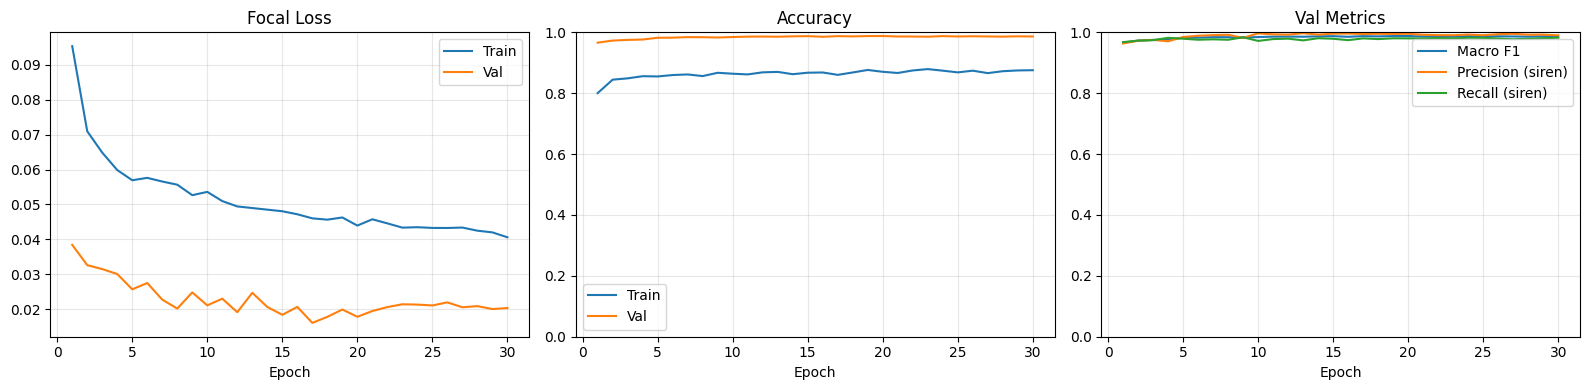

In [ ]:
import matplotlib.pyplot as plt
ep = range(1, len(history['train_loss'])+1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(ep, history['train_loss'], label='Train'); axes[0].plot(ep, history['val_loss'], label='Val')
axes[0].set_title('Focal Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep, history['train_acc'], label='Train'); axes[1].plot(ep, history['val_acc'], label='Val')
axes[1].set_title('Accuracy'); axes[1].set_ylim(0,1); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(ep, history['val_f1'], label='Macro F1')
axes[2].plot(ep, history['val_prec'], label='Precision (siren)')
axes[2].plot(ep, history['val_rec'],  label='Recall (siren)')
axes[2].set_title('Val Metrics'); axes[2].set_ylim(0,1); axes[2].legend(); axes[2].grid(alpha=0.3)
for ax in axes: ax.set_xlabel('Epoch')
plt.tight_layout(); plt.savefig('/content/curves_v4.png', dpi=150); plt.show()

Threshold (từ val set): 0.545  |  Val F1: 0.9879

KẾT QUẢ TEST SET — single-window (baseline)
              precision    recall  f1-score   support

    No Siren       0.98      1.00      0.99     11169
       Siren       1.00      0.98      0.99     10854

    accuracy                           0.99     22023
   macro avg       0.99      0.99      0.99     22023
weighted avg       0.99      0.99      0.99     22023

ROC-AUC: 0.9959

MAJORITY VOTING — theo Tran & Tsai 2020
Vote window=5, min_votes=3:
              precision    recall  f1-score   support

    No Siren       0.98      1.00      0.99     11169
       Siren       1.00      0.98      0.99     10854

    accuracy                           0.99     22023
   macro avg       0.99      0.99      0.99     22023
weighted avg       0.99      0.99      0.99     22023

False Positive: single=5469 → majority_vote=33 (giảm 5436)
False Negative: single=5618 → majority_vote=183


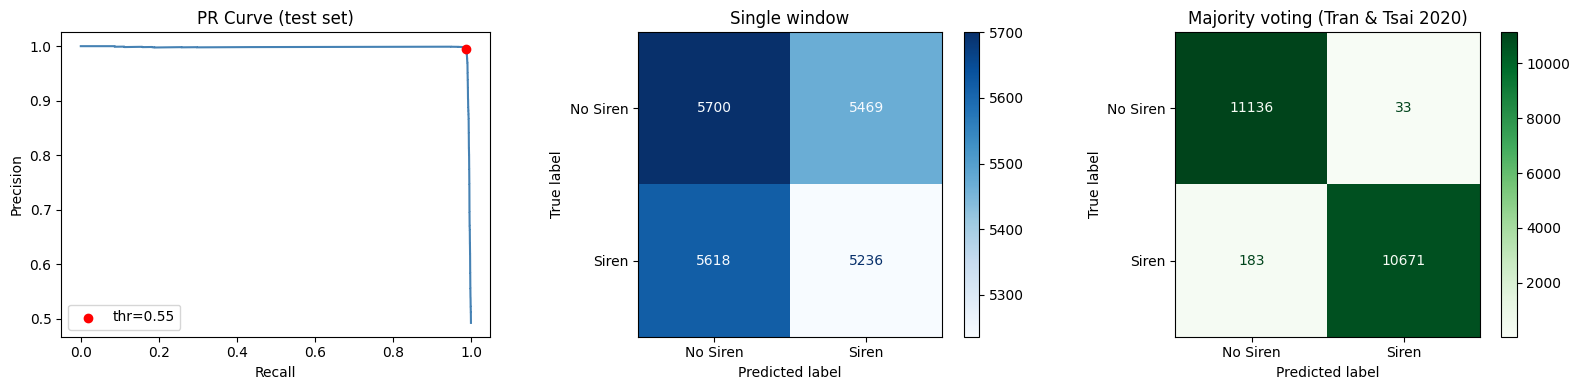

In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              precision_recall_curve)
from collections import deque

model.load_state_dict(torch.load(MODEL_SAVE, map_location=DEVICE))
model.eval()

def get_probs(dl):
    probs, labels = [], []
    with torch.no_grad():
        for mel, mfcc, lbl in dl:
            out  = model(mel.to(DEVICE), mfcc.to(DEVICE))
            prob = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
            probs.extend(prob); labels.extend(lbl.numpy())
    return np.array(probs), np.array(labels)

val_probs, val_labels = get_probs(val_dl)
prec_v, rec_v, thr_v  = precision_recall_curve(val_labels, val_probs)
f1_v  = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-8)
best_i = np.argmax(f1_v[:-1])
BEST_THR = float(thr_v[best_i])
print(f'Threshold (từ val set): {BEST_THR:.3f}  |  Val F1: {f1_v[best_i]:.4f}')

# Đánh giá trên TEST set
test_probs, test_labels = get_probs(test_dl)
auc = roc_auc_score(test_labels, test_probs)

print('\n' + '='*60)
print('KẾT QUẢ TEST SET — single-window (baseline)')
print('='*60)
preds_opt = (test_probs >= BEST_THR).astype(int)
print(classification_report(test_labels, preds_opt, target_names=['No Siren','Siren']))
print(f'ROC-AUC: {auc:.4f}')

# ── Majority Voting (Tran & Tsai 2020) ─────────────────────────────
print('\n' + '='*60)
print('MAJORITY VOTING — theo Tran & Tsai 2020')
print('='*60)

class MajorityVoter:
    """
    Tran & Tsai 2020: 'majority voting of predictions corresponding
    to all input segments to obtain the final prediction result.'

    vote_window=5: vote qua 5 windows liên tiếp (= 5×0.17s ≈ 0.85s lag)
    min_votes=3  : cần ≥3/5 để báo còi
    """
    def __init__(self, threshold=0.5, vote_window=5, min_votes=3):
        self.thr        = threshold
        self.history    = deque(maxlen=vote_window)
        self.min_votes  = min_votes

    def update(self, prob):
        self.history.append(int(prob >= self.thr))
        if len(self.history) < self.min_votes:
            return int(prob >= self.thr)  # chưa đủ history — dùng single
        return int(sum(self.history) >= self.min_votes)

# Majority voting theo từng file gốc — không vote lẫn segments của file khác
test_df_sorted = test_df.sort_values('source_file').reset_index(drop=True)
test_ds_sorted = SirenDataset.__new__(SirenDataset)
test_ds_sorted.df      = test_df_sorted
test_ds_sorted.root    = Path(MERGED_DIR)
test_ds_sorted.augment = False
test_ds_sorted._load   = lambda idx: SirenDataset._load(test_ds_sorted, idx)
test_ds_sorted.__len__ = lambda: len(test_df_sorted)
test_ds_sorted.__getitem__ = lambda idx: SirenDataset.__getitem__(test_ds_sorted, idx)

test_dl_sorted = DataLoader(test_ds_sorted, batch_size=BATCH_SIZE,
                             shuffle=False, num_workers=2)
test_probs_s, test_labels_s = get_probs(test_dl_sorted)
src_files_s = test_df_sorted['source_file'].values

voter    = MajorityVoter(threshold=BEST_THR, vote_window=5, min_votes=3)
mv_preds = []
prev_src = None
for prob, src in zip(test_probs_s, src_files_s):
    if src != prev_src:          # file mới → reset voter
        voter = MajorityVoter(threshold=BEST_THR, vote_window=5, min_votes=3)
        prev_src = src
    mv_preds.append(voter.update(prob))

test_probs  = test_probs_s
test_labels = test_labels_s
mv_preds    = np.array(mv_preds)

print(f'Vote window=5, min_votes=3:')
print(classification_report(test_labels, mv_preds, target_names=['No Siren','Siren']))

tn,fp,fn,tp = confusion_matrix(test_labels, preds_opt).ravel()
tn2,fp2,fn2,tp2 = confusion_matrix(test_labels, mv_preds).ravel()
print(f'False Positive: single={fp} → majority_vote={fp2} (giảm {fp-fp2})')
print(f'False Negative: single={fn} → majority_vote={fn2}')

# Plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
prec_t, rec_t, thr_t = precision_recall_curve(test_labels, test_probs)
axes[0].plot(rec_t, prec_t, 'steelblue')
axes[0].scatter(rec_t[np.argmax(2*prec_t*rec_t/(prec_t+rec_t+1e-8))],
               prec_t[np.argmax(2*prec_t*rec_t/(prec_t+rec_t+1e-8))],
               color='red', zorder=5, label=f'thr={BEST_THR:.2f}')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('PR Curve (test set)'); axes[0].legend()

ConfusionMatrixDisplay(confusion_matrix(test_labels, preds_opt),
    display_labels=['No Siren','Siren']).plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Single window')

ConfusionMatrixDisplay(confusion_matrix(test_labels, mv_preds),
    display_labels=['No Siren','Siren']).plot(ax=axes[2], cmap='Greens')
axes[2].set_title('Majority voting (Tran & Tsai 2020)')

plt.tight_layout(); plt.savefig('/content/eval_v4.png', dpi=150); plt.show()

Tổng lỗi: 221 / 22023
False Positives (noise→siren): 36
False Negatives (siren→noise): 185


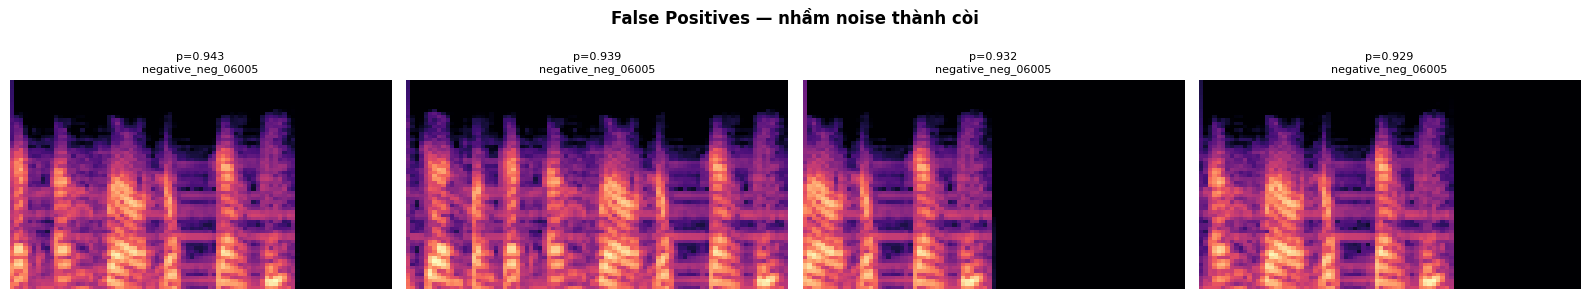

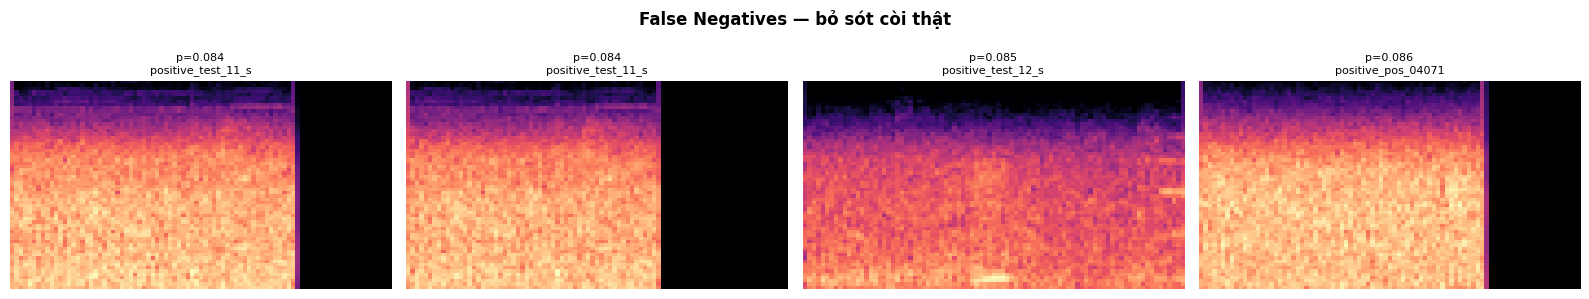

In [ ]:
test_df_r = test_df.reset_index(drop=True)
model.eval()
all_probs_list = []
with torch.no_grad():
    for mel, mfcc, _ in test_dl:
        out = model(mel.to(DEVICE), mfcc.to(DEVICE))
        all_probs_list.extend(torch.softmax(out,1)[:,1].cpu().tolist())

n = min(len(test_df_r), len(all_probs_list))
res = test_df_r.iloc[:n].copy()
res['prob']    = all_probs_list[:n]
res['pred']    = (res['prob'] >= BEST_THR).astype(int)
res['correct'] = res['label'] == res['pred']

fp_df = res[(res.pred==1)&(res.label==0)].sort_values('prob', ascending=False)
fn_df = res[(res.pred==0)&(res.label==1)].sort_values('prob')

print(f'Tổng lỗi: {(~res.correct).sum()} / {n}')
print(f'False Positives (noise→siren): {len(fp_df)}')
print(f'False Negatives (siren→noise): {len(fn_df)}')

def show_mel_errors(df, title, n_show=4):
    n = min(n_show, len(df))
    if n == 0: print(f'Không có lỗi: {title}'); return
    fig, axes = plt.subplots(1, n, figsize=(4*n, 3))
    if n == 1: axes = [axes]
    for ax, (_, row) in zip(axes, df.head(n).iterrows()):
        try:
            data = np.load(Path(MERGED_DIR) / row['npy_path'])
            ax.imshow(data['mel'], origin='lower', aspect='auto', cmap='magma')
            ax.set_title(f'p={row["prob"]:.3f}\n{Path(row["npy_path"]).stem[:18]}', fontsize=8)
        except: ax.set_title('load error')
        ax.axis('off')
    fig.suptitle(title, fontweight='bold'); plt.tight_layout(); plt.show()

show_mel_errors(fp_df, 'False Positives — nhầm noise thành còi')
show_mel_errors(fn_df, 'False Negatives — bỏ sót còi thật')

In [ ]:
import json
ONNX_PATH = '/content/siren_v4.onnx'

model.load_state_dict(torch.load(MODEL_SAVE, map_location='cpu'))
model.eval().cpu()

n_fr   = CLIP_LEN // HOP_LEN + 1
d_mel  = torch.randn(1, 1, N_MELS, n_fr)
d_mfcc = torch.randn(1, 1, N_MFCC, n_fr)

with torch.no_grad():
    torch.onnx.export(
        model,
        (d_mel, d_mfcc),
        ONNX_PATH,
        input_names  = ['mel', 'mfcc'],
        output_names = ['logits'],
        dynamic_axes = {
            'mel'   : {3: 'T_mel'},
            'mfcc'  : {3: 'T_mfcc'},
            'logits': {0: 'batch'},
        },
        opset_version = 17,
        dynamo        = False,
    )

print(f'✅ ONNX saved: {ONNX_PATH}')

import onnx
m = onnx.load(ONNX_PATH)
onnx.checker.check_model(m)
print(f'✅ ONNX valid')

cfg = {
    'version'      : 'v4',
    'architecture' : 'DualStream-CNN-BiLSTM-Attention',
    'format'       : 'onnx',
    'papers'       : ['Tran&Tsai2020','Tsai2025','Kong2020','Fatimah2020','Schroder2013','Ebizuka2019'],
    'threshold'    : BEST_THR,
    'vote_window'  : 5,
    'min_votes'    : 3,
    'sr'           : SR,
    'n_mels'       : N_MELS,
    'n_mfcc'       : N_MFCC,
    'hop_length'   : HOP_LEN,
    'n_fft'        : N_FFT,
    'fmin'         : FMIN,
    'fmax'         : FMAX,
    'clip_sec'     : CLIP_SEC,
    'stride_sec'   : STRIDE_SEC,
    'pre_emphasis' : PRE_EMPH,
    'mel_shape'    : [1, 1, N_MELS, n_fr],
    'mfcc_shape'   : [1, 1, N_MFCC, n_fr],
    'mel_freq_after_pool'  : MEL_FREQ_AFTER_POOL,
    'mfcc_freq_after_pool' : MFCC_FREQ_AFTER_POOL,
    'best_val_f1'  : float(best_f1),
    'roc_auc'      : float(auc),
}
CFG_PATH = '/content/config_v4.json'
with open(CFG_PATH, 'w') as f: json.dump(cfg, f, indent=2)
print(json.dumps(cfg, indent=2))


/tmp/ipykernel_2184/3255596736.py:12: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset9.py:4445: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with LSTM can cause an error when running the ONNX model with a different batch size. Make sure to save the model with a batch size of 1, or define the initial states (h0/c0) as inputs of the model. 
  return _generic_rnn(


✅ ONNX saved: /content/siren_v4.onnx
✅ ONNX valid
{
  "version": "v4",
  "architecture": "DualStream-CNN-BiLSTM-Attention",
  "format": "onnx",
  "papers": [
    "Tran&Tsai2020",
    "Tsai2025",
    "Kong2020",
    "Fatimah2020",
    "Schroder2013",
    "Ebizuka2019"
  ],
  "threshold": 0.545237123966217,
  "vote_window": 5,
  "min_votes": 3,
  "sr": 22050,
  "n_mels": 64,
  "n_mfcc": 40,
  "hop_length": 512,
  "n_fft": 1024,
  "fmin": 300,
  "fmax": 3500,
  "clip_sec": 2.0,
  "stride_sec": 0.17,
  "pre_emphasis": 0.97,
  "mel_shape": [
    1,
    1,
    64,
    87
  ],
  "mfcc_shape": [
    1,
    1,
    40,
    87
  ],
  "mel_freq_after_pool": 16,
  "mfcc_freq_after_pool": 10,
  "best_val_f1": 0.9879160017232285,
  "roc_auc": 0.9958812678812375
}


In [ ]:
pip install onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 44.4 MB/s eta 0:00:00


In [ ]:
import shutil
SAVE_DIR = '/content/drive/MyDrive/siren_v4_output'
os.makedirs(SAVE_DIR, exist_ok=True)
for src in [MODEL_SAVE, ONNX_PATH, CFG_PATH,
            '/content/curves_v4.png', '/content/eval_v4.png',
            str(Path(MERGED_DIR)/'metadata_v4.csv')]:
    if os.path.exists(src):
        shutil.copy(src, SAVE_DIR)
        print(f'✅ {os.path.basename(src)}')
print(f'Saved to: {SAVE_DIR}')

✅ siren_best_v4.pth
✅ siren_v4.onnx
✅ config_v4.json
✅ curves_v4.png
✅ eval_v4.png
✅ metadata_v4.csv
Saved to: /content/drive/MyDrive/siren_v4_output


In [ ]:
from google.colab import files
files.download(MODEL_SAVE)
files.download(ONNX_PATH)
files.download(CFG_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from pathlib import Path
import os, numpy as np, pandas as pd

FP_NEW_DIR   = '/content/drive/MyDrive/fp_new'          # WAV false positive mới
FT_WORK_DIR  = '/content/ft_work'                       # thư mục làm việc tạm
MODEL_SAVE = '/content/drive/MyDrive/siren_v4_output/siren_best_v4.pth'

FT_NPY_DIR   = Path(FT_WORK_DIR) / 'ft_npy'
FT_SPLIT_DIR = Path(FT_WORK_DIR) / 'ft_split'
FT_NPY_DIR.mkdir(parents=True, exist_ok=True)
FT_SPLIT_DIR.mkdir(parents=True, exist_ok=True)

# Đếm WAV mới
fp_wavs = sorted(
    list(Path(FP_NEW_DIR).glob('*.wav')) +
    list(Path(FP_NEW_DIR).glob('*.WAV'))
)
print(f'✅ FP WAV mới: {len(fp_wavs)} files')
for f in fp_wavs: print(f'   {f.name}')

✅ FP WAV mới: 1575 files
   test_10_detect_149.41s.wav
   test_10_detect_2462.63s.wav
   test_10_detect_2906.78s.wav
   test_10_detect_473.22s.wav
   test_10_detect_490.38s.wav
   test_10_detect_491.40s.wav
   test_10_detect_64.25s.wav
   test_13_detect_1008.65s.wav
   test_13_detect_116.43s.wav
   test_13_detect_1279.59s.wav
   test_13_detect_1337.04s.wav
   test_13_detect_1516.71s.wav
   test_13_detect_1529.29s.wav
   test_13_detect_1581.13s.wav
   test_13_detect_1688.38s.wav
   test_13_detect_1940.80s.wav
   test_13_detect_1950.49s.wav
   test_13_detect_2050.61s.wav
   test_13_detect_2079.67s.wav
   test_13_detect_2180.81s.wav
   test_13_detect_23.46s.wav
   test_13_detect_2385.46s.wav
   test_13_detect_2405.69s.wav
   test_13_detect_2620.88s.wav
   test_13_detect_2622.92s.wav
   test_13_detect_266.69s.wav
   test_13_detect_2855.45s.wav
   test_13_detect_2857.49s.wav
   test_13_detect_2888.25s.wav
   test_13_detect_2890.29s.wav
   test_13_detect_2892.33s.wav
   test_13_detect_2894.3

In [ ]:
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# ── Số file OLD lấy mỗi class ─────────────────────────────────
# Quy tắc: bằng số FP mới, tối thiểu 20, tối đa 150
N_SAMPLE = len(fp_wavs)
print(f'Sẽ sample {N_SAMPLE} file mỗi class từ dataset cũ')

# ── Lấy path WAV từ dataset gốc ───────────────────────────────
rng = np.random.default_rng(42)

old_pos = sorted(list(Path(OLD_DIR, 'positive').glob('*.wav')) +
                 list(Path(OLD_DIR, 'positive').glob('*.WAV')))
old_neg = sorted(list(Path(OLD_DIR, 'negative').glob('*.wav')) +
                 list(Path(OLD_DIR, 'negative').glob('*.WAV')))

s_pos = rng.choice(old_pos, size=min(N_SAMPLE, len(old_pos)), replace=False).tolist()
s_neg = rng.choice(old_neg, size=min(N_SAMPLE, len(old_neg)), replace=False).tolist()

print(f'Sampled: pos={len(s_pos)} | neg={len(s_neg)} | fp_new={len(fp_wavs)}')
print(f'Tổng files sẽ extract: {len(s_pos)+len(s_neg)+len(fp_wavs)}')

# ── Extract NPZ ───────────────────────────────────────────────
all_records = []
errors = []

def extract_save(wav_path, label, tag):
    try:
        feats_list = wav_to_features(str(wav_path))   # function từ v4
        for i, feats in enumerate(feats_list):
            name = f'{tag}_{Path(wav_path).stem}_s{i:03d}.npz'
            np.savez_compressed(FT_NPY_DIR / name,
                                mel=feats['mel'], mfcc=feats['mfcc'])
            all_records.append({
                'npy_path': str(FT_NPY_DIR / name),
                'label'   : label,
                'tag'     : tag,
                'src'     : str(wav_path),
            })
    except Exception as e:
        errors.append((str(wav_path), str(e)))

jobs = ([(f, 1, 'old_pos') for f in s_pos] +
        [(f, 0, 'old_neg') for f in s_neg] +
        [(f, 0, 'fp_new')  for f in fp_wavs])

for wav, lbl, tag in tqdm(jobs, desc='Extract NPZ'):
    extract_save(wav, lbl, tag)

df_all = pd.DataFrame(all_records)
print(f'\nTổng segments: {len(df_all)}')
print(df_all.groupby(['tag','label']).size().to_string())
if errors:
    print(f'\n⚠️  Lỗi: {len(errors)} file')
    for p, e in errors: print(f'   {Path(p).name}: {e}')

Sẽ sample 1575 file mỗi class từ dataset cũ
Sampled: pos=1575 | neg=1575 | fp_new=1575
Tổng files sẽ extract: 4725


Extract NPZ: 100%|██████████| 4725/4725 [10:00<00:00,  7.87it/s]



Tổng segments: 42525
tag      label
fp_new   0        14175
old_neg  0        14175
old_pos  1        14175


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

src_df = df_all.drop_duplicates('src')[['src','label','tag']].reset_index(drop=True)
tr_src, tmp_src = train_test_split(src_df, test_size=0.3,
                                    random_state=42, stratify=src_df.label)
vl_src, te_src  = train_test_split(tmp_src, test_size=0.5,
                                    random_state=42, stratify=tmp_src.label)

def segs_of(src_set):
    return df_all[df_all.src.isin(src_set.src)].reset_index(drop=True)

ft_train = segs_of(tr_src)
ft_val   = segs_of(vl_src)
ft_test  = segs_of(te_src)

ft_train.to_csv(FT_SPLIT_DIR / 'train.csv', index=False)
ft_val.to_csv(  FT_SPLIT_DIR / 'val.csv',   index=False)
ft_test.to_csv( FT_SPLIT_DIR / 'test.csv',  index=False)

for name, df in [('train', ft_train), ('val', ft_val), ('test', ft_test)]:
    fp = (df.tag=='fp_new').sum()
    print(f'{name:6s}: {len(df):>5} segs '
          f'(pos={(df.label==1).sum()}, neg={(df.label==0).sum()}, fp_new_segs={fp})')

# Kiểm tra leak
assert not (set(ft_train.src) & set(ft_val.src)), '❌ LEAK train-val!'
assert not (set(ft_train.src) & set(ft_test.src)), '❌ LEAK train-test!'
print('✅ Không có data leak')

# ── Dataset ───────────────────────────────────────────────────
class FTDataset(Dataset):
    def __init__(self, csv_path, augment=False):
        self.df = pd.read_csv(csv_path).reset_index(drop=True)
        self.aug = augment

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        data = np.load(row['npy_path'])
        mel  = data['mel'].copy()
        mfcc = data['mfcc'].copy()
        if self.aug:
            F, T = mel.shape
            # Time shift nhẹ
            if np.random.rand() < 0.5:
                s = np.random.randint(-T//10, T//10+1)
                mel = np.roll(mel, s, axis=1); mfcc = np.roll(mfcc, s, axis=1)
            # 1 freq mask + 1 time mask (nhẹ hơn v4)
            if np.random.rand() < 0.5:
                f = np.random.randint(1, max(2, F//8))
                mel[np.random.randint(0,F-f):, :][:f] = mel.mean()
            if np.random.rand() < 0.5:
                t = np.random.randint(1, max(2, T//8))
                t0 = np.random.randint(0, T-t)
                mel[:, t0:t0+t] = mel.mean(); mfcc[:, t0:t0+t] = mfcc.mean()
        return (torch.tensor(mel).unsqueeze(0),
                torch.tensor(mfcc).unsqueeze(0),
                int(row['label']))

FT_BATCH = 32
ft_train_dl = DataLoader(FTDataset(FT_SPLIT_DIR/'train.csv', augment=True),
                          batch_size=FT_BATCH, shuffle=True,  num_workers=2, pin_memory=True)
ft_val_dl   = DataLoader(FTDataset(FT_SPLIT_DIR/'val.csv'),
                          batch_size=FT_BATCH, shuffle=False, num_workers=2, pin_memory=True)
ft_test_dl  = DataLoader(FTDataset(FT_SPLIT_DIR/'test.csv'),
                          batch_size=FT_BATCH, shuffle=False, num_workers=2, pin_memory=True)

# Class weights
n0 = (ft_train.label==0).sum(); n1 = (ft_train.label==1).sum(); tot = n0+n1
FT_CW = torch.tensor([tot/(2*n0), tot/(2*n1)], dtype=torch.float32).to(DEVICE)
print(f'Class weights: label0={FT_CW[0]:.3f}, label1={FT_CW[1]:.3f}')

train : 29763 segs (pos=9918, neg=19845, fp_new_segs=9936)
val   :  6381 segs (pos=2133, neg=4248, fp_new_segs=2079)
test  :  6381 segs (pos=2124, neg=4257, fp_new_segs=2160)
✅ Không có data leak
Class weights: label0=0.750, label1=1.500


In [ ]:
# Load lại weights v4 tốt nhất
MODEL_SAVE = '/content/drive/MyDrive/siren_v4_output/siren_best_v4.pth'

ft_model = SirenNetV4(n_classes=2, base_ch=48,
                       lstm_hidden=256, lstm_layers=2).to(DEVICE)
ft_model.load_state_dict(
    torch.load(MODEL_SAVE, map_location=DEVICE))

# Freeze CNN — giữ nguyên feature extractor
for p in ft_model.mel_cnn.parameters():  p.requires_grad = False
for p in ft_model.mfcc_cnn.parameters(): p.requires_grad = False
# Train BiLSTM + Attention + Classifier
for p in ft_model.bilstm.parameters():     p.requires_grad = True
for p in ft_model.attn_w.parameters():     p.requires_grad = True
for p in ft_model.classifier.parameters(): p.requires_grad = True

frozen    = sum(p.numel() for p in ft_model.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
print(f'✅ Loaded: {MODEL_SAVE}')
print(f'   Frozen  : {frozen:,} params  (CNN — ❄️ giữ nguyên)')
print(f'   Trainable: {trainable:,} params (BiLSTM+Attn+Classifier — 🔥 train)')

✅ Loaded: /content/drive/MyDrive/siren_v4_output/siren_best_v4.pth
   Frozen  : 806,184 params  (CNN — ❄️ giữ nguyên)
   Trainable: 3,024,259 params (BiLSTM+Attn+Classifier — 🔥 train)


In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import f1_score, precision_score, recall_score

FT_EPOCHS  = 30
FT_LR      = 5e-5   # << nhỏ hơn v4 (3e-4) để không quên kiến thức cũ
FT_PATIENCE = 8
FT_SAVE    = '/content/siren_v4ft_best.pth'

ft_opt  = AdamW(filter(lambda p: p.requires_grad, ft_model.parameters()),
                 lr=FT_LR, weight_decay=1e-4)
ft_sch  = CosineAnnealingLR(ft_opt, T_max=FT_EPOCHS, eta_min=FT_LR/10)
ft_loss = FocalLoss(alpha=FT_CW, gamma=2.0, label_smoothing=0.05)

best_f1_ft = 0.0
counter    = 0
ft_hist    = {k: [] for k in ['tr_loss','tr_acc','vl_loss','vl_acc','vl_f1']}

HDR = f'{"Ep":>4} {"Tr-Loss":>9} {"Tr-Acc":>8} {"Vl-Loss":>9} {"Vl-Acc":>8} {"F1":>7} {"Prec":>7} {"Rec":>7}'
print(f'Fine-tune {FT_EPOCHS} epochs | LR={FT_LR} | Patience={FT_PATIENCE}')
print(HDR); print('─'*len(HDR))

for ep in range(1, FT_EPOCHS+1):
    ft_model.train()
    ft_model.mel_cnn.eval()   # BatchNorm dùng running stats cũ
    ft_model.mfcc_cnn.eval()

    tl, tok, ttot = 0., 0, 0
    for mel, mfcc, lbl in ft_train_dl:
        mel, mfcc, lbl = mel.to(DEVICE), mfcc.to(DEVICE), lbl.to(DEVICE)
        ft_opt.zero_grad()
        out  = ft_model(mel, mfcc)
        loss = ft_loss(out, lbl)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            filter(lambda p: p.requires_grad, ft_model.parameters()), 1.0)
        ft_opt.step()
        tl += loss.item()*len(lbl); tok += (out.argmax(1)==lbl).sum().item(); ttot += len(lbl)
    ft_sch.step()

    ft_model.eval()
    vl, vp, vlab = 0., [], []
    with torch.no_grad():
        for mel, mfcc, lbl in ft_val_dl:
            mel, mfcc, lbl = mel.to(DEVICE), mfcc.to(DEVICE), lbl.to(DEVICE)
            out = ft_model(mel, mfcc)
            vl += ft_loss(out, lbl).item()*len(lbl)
            vp.extend(out.argmax(1).cpu().tolist())
            vlab.extend(lbl.cpu().tolist())

    f1  = f1_score(vlab, vp, average='macro', zero_division=0)
    pre = precision_score(vlab, vp, pos_label=1, zero_division=0)
    rec = recall_score(vlab, vp, pos_label=1, zero_division=0)
    for k,v in zip(ft_hist, [tl/ttot, tok/ttot, vl/len(vlab),
                              sum(p==l for p,l in zip(vp,vlab))/len(vlab), f1]):
        ft_hist[k].append(v)

    mark = ''
    if f1 > best_f1_ft:
        best_f1_ft = f1; torch.save(ft_model.state_dict(), FT_SAVE)
        mark = ' ◄ saved'; counter = 0
    else:
        counter += 1; mark = f' [{counter}/{FT_PATIENCE}]'

    print(f'{ep:4d} {tl/ttot:9.4f} {tok/ttot:8.3f} {vl/len(vlab):9.4f} '
          f'{sum(p==l for p,l in zip(vp,vlab))/len(vlab):8.3f} '
          f'{f1:7.3f} {pre:7.3f} {rec:7.3f}{mark}')
    if counter >= FT_PATIENCE:
        print(f'🛑 Early stop tại epoch {ep}'); break

print(f'\n✅ Best val F1: {best_f1_ft:.4f}')

Fine-tune 30 epochs | LR=5e-05 | Patience=8
  Ep   Tr-Loss   Tr-Acc   Vl-Loss   Vl-Acc      F1    Prec     Rec
──────────────────────────────────────────────────────────────────
   1    0.0252    0.970    0.0169    0.985   0.984   0.977   0.979 ◄ saved
   2    0.0144    0.988    0.0144    0.991   0.990   0.989   0.984 ◄ saved
   3    0.0115    0.991    0.0130    0.992   0.990   0.988   0.986 ◄ saved
   4    0.0099    0.992    0.0123    0.992   0.991   0.989   0.987 ◄ saved
   5    0.0088    0.993    0.0123    0.992   0.990   0.987   0.988 [1/8]
   6    0.0076    0.994    0.0128    0.993   0.992   0.994   0.985 ◄ saved
   7    0.0075    0.994    0.0119    0.993   0.992   0.992   0.987 ◄ saved
   8    0.0068    0.995    0.0124    0.993   0.992   0.990   0.988 [1/8]
   9    0.0064    0.995    0.0129    0.993   0.992   0.994   0.986 ◄ saved
  10    0.0061    0.995    0.0129    0.993   0.992   0.993   0.986 ◄ saved
  11    0.0055    0.996    0.0140    0.993   0.992   0.993   0.986 [1/8]
  1

Threshold mới (val set): 0.567

KẾT QUẢ TEST SET — Fine-tune
              precision    recall  f1-score   support

    No Siren       0.99      0.99      0.99      4257
       Siren       0.99      0.98      0.98      2124

    accuracy                           0.99      6381
   macro avg       0.99      0.99      0.99      6381
weighted avg       0.99      0.99      0.99      6381

ROC-AUC: 0.9982

FP rate theo nhóm:
  old_pos     : acc=0.978 | FP=0/0 (0.0%)
  old_neg     : acc=0.997 | FP=7/2097 (0.3%)
  fp_new      : acc=0.993 | FP=15/2160 (0.7%)


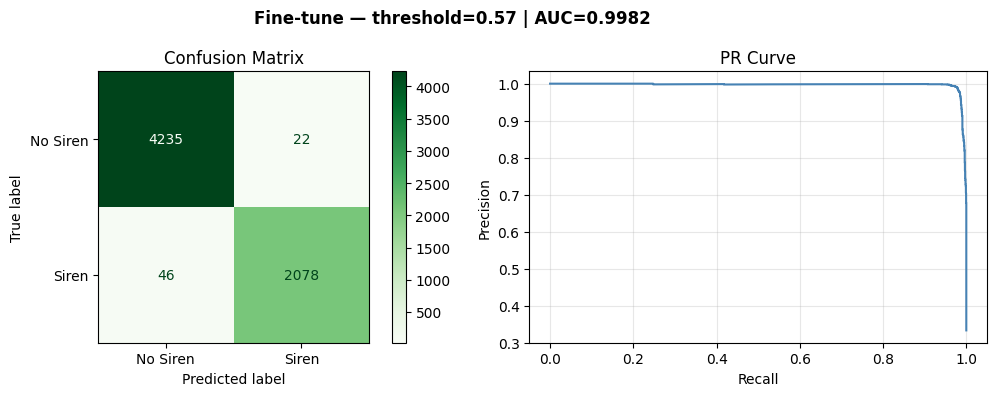

In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              precision_recall_curve)
import matplotlib.pyplot as plt

ft_model.load_state_dict(torch.load(FT_SAVE, map_location=DEVICE))
ft_model.eval()

def get_probs_ft(dl):
    probs, labels = [], []
    with torch.no_grad():
        for mel, mfcc, lbl in dl:
            out = ft_model(mel.to(DEVICE), mfcc.to(DEVICE))
            probs.extend(torch.softmax(out,1)[:,1].cpu().tolist())
            labels.extend(lbl.tolist())
    return np.array(probs), np.array(labels)

# Threshold tối ưu từ VAL
vp, vl  = get_probs_ft(ft_val_dl)
prec_v, rec_v, thr_v = precision_recall_curve(vl, vp)
f1_v    = 2*prec_v*rec_v/(prec_v+rec_v+1e-8)
FT_THR  = float(thr_v[np.argmax(f1_v[:-1])])
print(f'Threshold mới (val set): {FT_THR:.3f}')

# Test set
tp, tl  = get_probs_ft(ft_test_dl)
preds   = (tp >= FT_THR).astype(int)
auc     = roc_auc_score(tl, tp)

print('\n' + '='*55)
print('KẾT QUẢ TEST SET — Fine-tune')
print('='*55)
print(classification_report(tl, preds, target_names=['No Siren','Siren']))
print(f'ROC-AUC: {auc:.4f}')

# Phân tích theo tag
print('\nFP rate theo nhóm:')
n = min(len(ft_test), len(tl))
res = ft_test.iloc[:n].copy()
res['prob'] = tp[:n]; res['pred'] = (res['prob']>=FT_THR).astype(int)
for tag in res.tag.unique():
    sub = res[res.tag==tag]
    neg = (sub.label==0).sum()
    fp_cnt = ((sub.pred==1)&(sub.label==0)).sum()
    acc = (sub.pred==sub.label).mean()
    print(f'  {tag:<12}: acc={acc:.3f} | FP={fp_cnt}/{neg} '
          f'({100*fp_cnt/max(neg,1):.1f}%)')

# Plots
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle(f'Fine-tune — threshold={FT_THR:.2f} | AUC={auc:.4f}', fontweight='bold')
ConfusionMatrixDisplay(
    confusion_matrix(tl, preds), display_labels=['No Siren','Siren']
).plot(ax=axes[0], cmap='Greens'); axes[0].set_title('Confusion Matrix')
prec_t, rec_t, _ = precision_recall_curve(tl, tp)
axes[1].plot(rec_t, prec_t, 'steelblue'); axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision'); axes[1].set_title('PR Curve'); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/eval_v4ft.png', dpi=150); plt.show()

In [ ]:
import json, shutil

ONNX_FT = '/content/siren_v4ft.onnx'
ft_model.load_state_dict(torch.load(FT_SAVE, map_location='cpu'))
ft_model.eval().cpu()

n_fr   = CLIP_LEN // HOP_LEN + 1
with torch.no_grad():
    torch.onnx.export(
        ft_model,
        (torch.randn(1,1,N_MELS,n_fr), torch.randn(1,1,N_MFCC,n_fr)),
        ONNX_FT,
        input_names=['mel','mfcc'], output_names=['logits'],
        dynamic_axes={'mel':{3:'T'},'mfcc':{3:'T'},'logits':{0:'B'}},
        opset_version=17, dynamo=False,
    )
import onnx; onnx.checker.check_model(onnx.load(ONNX_FT))
print(f'✅ ONNX: {ONNX_FT}')

# Config cập nhật threshold mới
cfg_ft = {
    'version': 'v4ft', 'base': 'v4',
    'strategy': 'frozen_cnn_train_bilstm',
    'threshold': float(FT_THR), 'vote_window': 5, 'min_votes': 3,
    'sr': SR, 'n_mels': N_MELS, 'n_mfcc': N_MFCC,
    'hop_length': HOP_LEN, 'n_fft': N_FFT,
    'fmin': FMIN, 'fmax': FMAX,
    'clip_sec': CLIP_SEC, 'stride_sec': STRIDE_SEC,
    'pre_emphasis': PRE_EMPH,
    'mel_freq_after_pool': MEL_FREQ_AFTER_POOL,
    'mfcc_freq_after_pool': MFCC_FREQ_AFTER_POOL,
    'best_val_f1': float(best_f1_ft), 'roc_auc': float(auc),
    'fp_new_files': len(fp_wavs),
}
CFG_FT = '/content/config_v4ft.json'
with open(CFG_FT,'w') as f: json.dump(cfg_ft, f, indent=2)
print(json.dumps(cfg_ft, indent=2))

# Lưu về Drive (cùng folder siren_v4_output)
SAVE_DIR = '/content/drive/MyDrive/siren_v4_output'
for src in [FT_SAVE, ONNX_FT, CFG_FT, '/content/eval_v4ft.png']:
    if os.path.exists(src):
        shutil.copy(src, SAVE_DIR)
        print(f'  ✅ {os.path.basename(src)}')

# Download
from google.colab import files
for f in [FT_SAVE, ONNX_FT, CFG_FT]:
    if os.path.exists(f): files.download(f)

/tmp/ipykernel_1661/2798037121.py:9: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset9.py:4445: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with LSTM can cause an error when running the ONNX model with a different batch size. Make sure to save the model with a batch size of 1, or define the initial states (h0/c0) as inputs of the model. 
  return _generic_rnn(


✅ ONNX: /content/siren_v4ft.onnx
{
  "version": "v4ft",
  "base": "v4",
  "strategy": "frozen_cnn_train_bilstm",
  "threshold": 0.5672154426574707,
  "vote_window": 5,
  "min_votes": 3,
  "sr": 22050,
  "n_mels": 64,
  "n_mfcc": 40,
  "hop_length": 512,
  "n_fft": 1024,
  "fmin": 300,
  "fmax": 3500,
  "clip_sec": 2.0,
  "stride_sec": 0.17,
  "pre_emphasis": 0.97,
  "mel_freq_after_pool": 16,
  "mfcc_freq_after_pool": 10,
  "best_val_f1": 0.9929428299550491,
  "roc_auc": 0.9982107679519321,
  "fp_new_files": 1575
}
  ✅ siren_v4ft_best.pth
  ✅ siren_v4ft.onnx
  ✅ config_v4ft.json
  ✅ eval_v4ft.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
pip install onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 40.4 MB/s eta 0:00:00


In [ ]:
import torch, random, numpy as np, os

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')
print(f'GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')


PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4


In [ ]:
!pip install -q librosa soundfile onnx onnxsim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 47.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile

OLD_ZIP   = '/content/drive/MyDrive/dataset.zip'
OLD_DIR   = '/content/dataset'
WEIGHT_V4 = '/content/drive/MyDrive/siren_v4_output/siren_v4ft_best.pth'
OUT_DIR   = '/content/drive/MyDrive/siren_gru_output'

os.makedirs(OUT_DIR, exist_ok=True)

if not os.path.exists(OLD_DIR):
    print('Giải nén dataset...')
    with zipfile.ZipFile(OLD_ZIP, 'r') as z:
        z.extractall('/content')
    print('Done')
else:
    print(f'Dataset đã có: {OLD_DIR}')

!find {OLD_DIR} -maxdepth 2 -type d


Mounted at /content/drive
Giải nén dataset...
Done
find: ‘/content/dataset’: No such file or directory


In [ ]:
!find {OLD_DIR} -maxdepth 2 -type d

/content/dataset
/content/dataset/positive
/content/dataset/negative


In [ ]:
SR         = 22050
N_MELS     = 64
N_MFCC     = 40
HOP_LEN    = 512
N_FFT      = 1024
FMIN       = 300
FMAX       = 3500
CLIP_SEC   = 2.0
CLIP_LEN   = int(CLIP_SEC * SR)
STRIDE_SEC = 0.17
PRE_EMPH   = 0.97

MEL_FREQ_AFTER_POOL  = N_MELS // 4   # 16
MFCC_FREQ_AFTER_POOL = N_MFCC // 4   # 10
N_FRAMES = CLIP_LEN // HOP_LEN + 1

print(f'SR={SR} | N_MELS={N_MELS} | N_MFCC={N_MFCC} | HOP={HOP_LEN}')
print(f'Clip: {CLIP_SEC}s -> {N_FRAMES} frames')
print(f'Input mel:  (1, 1, {N_MELS}, {N_FRAMES})')
print(f'Input mfcc: (1, 1, {N_MFCC}, {N_FRAMES})')


SR=22050 | N_MELS=64 | N_MFCC=40 | HOP=512
Clip: 2.0s -> 87 frames
Input mel:  (1, 1, 64, 87)
Input mfcc: (1, 1, 40, 87)


In [ ]:
import librosa
import numpy as np

def pre_emphasis(y, coeff=PRE_EMPH):
    return np.append(y[0], y[1:] - coeff * y[:-1])

def bandpass_filter(y, sr, lo=500, hi=1800):
    from scipy.signal import butter, sosfilt
    sos = butter(4, [lo, hi], btype='band', fs=sr, output='sos')
    return sosfilt(sos, y)

def extract_mel(y, sr):
    y_pe = pre_emphasis(y)
    S = librosa.feature.melspectrogram(
        y=y_pe, sr=sr, n_fft=N_FFT, hop_length=HOP_LEN,
        n_mels=N_MELS, fmin=FMIN, fmax=FMAX, power=2.0)
    return librosa.power_to_db(S, ref=np.max).astype(np.float32)

def extract_mfcc(y, sr):
    y_pe = pre_emphasis(y)
    return librosa.feature.mfcc(
        y=y_pe, sr=sr, n_mfcc=N_MFCC,
        n_fft=N_FFT, hop_length=HOP_LEN, fmin=FMIN, fmax=FMAX
    ).astype(np.float32)

def normalize(x):
    return (x - x.mean()) / (x.std() + 1e-6)

def wav_to_features(wav_path):
    y, sr = librosa.load(wav_path, sr=SR, mono=True)
    y_bp  = bandpass_filter(y, sr)
    stride = int(STRIDE_SEC * sr)
    segs = []
    for start in range(0, len(y_bp) - CLIP_LEN + 1, stride):
        segs.append(y_bp[start:start + CLIP_LEN])
    if not segs:
        pad = np.zeros(CLIP_LEN); pad[:len(y_bp)] = y_bp; segs.append(pad)
    out = []
    for seg in segs:
        mel  = normalize(extract_mel(seg, SR))
        mfcc = normalize(extract_mfcc(seg, SR))
        def fix(x, T): return x[:, :T] if x.shape[1] >= T else np.pad(x, ((0,0),(0,T-x.shape[1])))
        out.append({'mel': fix(mel, N_FRAMES), 'mfcc': fix(mfcc, N_FRAMES)})
    return out

print('Feature extraction ready')


Feature extraction ready


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class CNNBranch(nn.Module):
    def __init__(self, in_ch=1, base=32, freq_after_pool=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, base,    3, padding=1, bias=False), nn.BatchNorm2d(base),    nn.GELU(),
            nn.Conv2d(base,   base,   3, padding=1, bias=False), nn.BatchNorm2d(base),    nn.GELU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.1),
            nn.Conv2d(base,   base*2, 3, padding=1, bias=False), nn.BatchNorm2d(base*2),  nn.GELU(),
            nn.Conv2d(base*2, base*2, 3, padding=1, bias=False), nn.BatchNorm2d(base*2),  nn.GELU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.15),
            nn.Conv2d(base*2, base*4, 3, padding=1, bias=False), nn.BatchNorm2d(base*4),  nn.GELU(),
            nn.Conv2d(base*4, base*4, 3, padding=1, bias=False), nn.BatchNorm2d(base*4),  nn.GELU(),
            nn.Dropout2d(0.2),
        )
        self.freq_pool = nn.AvgPool2d(kernel_size=(freq_after_pool, 1))

    def forward(self, x):
        h = self.net(x)
        h = self.freq_pool(h)
        return h.squeeze(2).permute(0, 2, 1)  # (B, T', C)


# ── Manual GRU — không dùng nn.GRU → ONNX không có Transpose (0,2,1,3) ──────
class ManualGRUCell(nn.Module):
    """1 GRU cell viết bằng Linear + sigmoid/tanh thuần."""
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.H  = hidden_size
        self.ih = nn.Linear(input_size,  hidden_size * 3)
        self.hh = nn.Linear(hidden_size, hidden_size * 3)

    def forward(self, x, h):
        gi = self.ih(x); gh = self.hh(h); H = self.H
        r = torch.sigmoid(gi[:, :H]    + gh[:, :H])      # reset gate
        z = torch.sigmoid(gi[:, H:2*H] + gh[:, H:2*H])   # update gate
        n = torch.tanh(   gi[:, 2*H:]  + r * gh[:, 2*H:]) # new gate
        return (1 - z) * n + z * h


class ManualGRU(nn.Module):
    """2-layer GRU chạy thủ công theo time step."""
    def __init__(self, input_size, hidden_size, num_layers=2, dropout=0.3):
        super().__init__()
        self.H = hidden_size
        self.L = num_layers
        self.dropout_p = dropout
        self.cells = nn.ModuleList([
            ManualGRUCell(input_size if i == 0 else hidden_size, hidden_size)
            for i in range(num_layers)
        ])

    def forward(self, x):
        B, T, _ = x.shape
        h = [torch.zeros(B, self.H, device=x.device, dtype=x.dtype)
             for _ in range(self.L)]
        outputs = []
        for t in range(T):
            inp = x[:, t, :]
            for i, cell in enumerate(self.cells):
                h[i] = cell(inp, h[i])
                inp   = h[i]
                if self.training and self.dropout_p > 0 and i < self.L - 1:
                    inp = F.dropout(inp, p=self.dropout_p)
            outputs.append(inp)
        return torch.stack(outputs, dim=1)  # (B, T, hidden_size)


class SirenNetV4_GRU(nn.Module):
    def __init__(self, n_classes=2, base_ch=48, gru_hidden=512, gru_layers=2):
        super().__init__()
        self.mel_cnn  = CNNBranch(in_ch=1, base=base_ch,      freq_after_pool=MEL_FREQ_AFTER_POOL)
        self.mfcc_cnn = CNNBranch(in_ch=1, base=base_ch // 2, freq_after_pool=MFCC_FREQ_AFTER_POOL)

        total_ch = base_ch * 4 + (base_ch // 2) * 4  # 288

        self.gru = ManualGRU(total_ch, gru_hidden, num_layers=gru_layers, dropout=0.3)

        self.attn_w = nn.Linear(gru_hidden, 1)
        self.classifier = nn.Sequential(
            nn.Linear(gru_hidden, 512), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(512, 128),        nn.GELU(), nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, mel, mfcc):
        mel_f  = self.mel_cnn(mel)
        mfcc_f = self.mfcc_cnn(mfcc)
        x = torch.cat([mel_f, mfcc_f], dim=-1)
        gru_out = self.gru(x)
        a   = torch.softmax(self.attn_w(gru_out), dim=1)
        ctx = (gru_out * a).sum(dim=1)
        return self.classifier(ctx)


model = SirenNetV4_GRU(n_classes=2, base_ch=48, gru_hidden=512, gru_layers=2).to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'Tong params: {total:,}')
with torch.no_grad():
    out = model(torch.randn(2,1,N_MELS,N_FRAMES).to(DEVICE),
                torch.randn(2,1,N_MFCC,N_FRAMES).to(DEVICE))
print(f'Output shape: {out.shape}  OK')

Tong params: 3,943,083
Output shape: torch.Size([2, 2])  OK


In [ ]:
sd_v4 = torch.load(WEIGHT_V4, map_location='cpu')

# Chi lay CNN keys
cnn_keys = {k: v for k, v in sd_v4.items()
            if k.startswith('mel_cnn.') or k.startswith('mfcc_cnn.')}

missing, unexpected = model.load_state_dict(cnn_keys, strict=False)
bad = [k for k in missing if not any(x in k for x in ['gru','attn','classifier'])]

print(f'CNN keys loaded : {len(cnn_keys)}')
print(f'Missing (expected GRU/attn/cls): {len(missing) - len(bad)}')
if bad: print(f'BAD missing: {bad}')
else:   print('Khong co CNN key bi miss')

# Freeze CNN
for p in model.mel_cnn.parameters():  p.requires_grad = False
for p in model.mfcc_cnn.parameters(): p.requires_grad = False

frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Frozen   : {frozen:,}  (CNN - giu nguyen tu v4)')
print(f'Trainable: {trainable:,}  (GRU + Attention + Classifier)')


CNN keys loaded : 72
Missing (expected GRU/attn/cls): 16
Khong co CNN key bi miss
Frozen   : 806,184  (CNN - giu nguyen tu v4)
Trainable: 3,136,899  (GRU + Attention + Classifier)


In [ ]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

LABEL_MAP = {'positive': 1, 'negative': 0}
NPY_DIR   = Path('/content/gru_npy')
NPY_DIR.mkdir(exist_ok=True)
SPLIT_DIR = Path('/content/gru_split')
SPLIT_DIR.mkdir(exist_ok=True)

existing = list(NPY_DIR.glob('*.npz'))
if len(existing) > 10:
    print(f'NPZ da co: {len(existing)} files - bo qua extract')
    records = [{'npy_path': str(f), 'label': 1 if f.stem.startswith('pos_') else 0,
                'src': '_'.join(f.stem.split('_')[:-1])} for f in existing]
else:
    records = []; errors = []
    for folder, label in LABEL_MAP.items():
        wavs = sorted(list(Path(OLD_DIR, folder).glob('*.wav')) +
                      list(Path(OLD_DIR, folder).glob('*.WAV')))
        pfx = 'pos' if label == 1 else 'neg'
        print(f'{folder}: {len(wavs)} files')
        for wp in tqdm(wavs, desc=folder):
            try:
                for i, feats in enumerate(wav_to_features(str(wp))):
                    name = f'{pfx}_{wp.stem}_s{i:03d}.npz'
                    np.savez_compressed(NPY_DIR / name, mel=feats['mel'], mfcc=feats['mfcc'])
                    records.append({'npy_path': str(NPY_DIR/name), 'label': label, 'src': str(wp)})
            except Exception as e:
                errors.append(str(e))
    print(f'Extract xong: {len(records)} segments, loi: {len(errors)}')

df_all = pd.DataFrame(records)
print(df_all.groupby('label').size().rename({0:'negative', 1:'positive'}))

# Split
src_df = df_all.drop_duplicates('src')[['src','label']].reset_index(drop=True)
tr_s, tmp = train_test_split(src_df, test_size=0.3, random_state=42, stratify=src_df.label)
vl_s, te_s = train_test_split(tmp,   test_size=0.5, random_state=42, stratify=tmp.label)

df_all[df_all.src.isin(tr_s.src)].to_csv(SPLIT_DIR/'train.csv', index=False)
df_all[df_all.src.isin(vl_s.src)].to_csv(SPLIT_DIR/'val.csv',   index=False)
df_all[df_all.src.isin(te_s.src)].to_csv(SPLIT_DIR/'test.csv',  index=False)

for name in ['train','val','test']:
    df = pd.read_csv(SPLIT_DIR/f'{name}.csv')
    print(f'{name:5s}: {len(df):>5} segs (pos={(df.label==1).sum()}, neg={(df.label==0).sum()})')
print('Khong co data leak:', not (set(pd.read_csv(SPLIT_DIR/'train.csv').src) &
                                   set(pd.read_csv(SPLIT_DIR/'val.csv').src)))


NPZ da co: 16312 files - bo qua extract
label
negative    8273
positive    8039
dtype: int64
train: 11418 segs (pos=5627, neg=5791)
val  :  2447 segs (pos=1206, neg=1241)
test :  2447 segs (pos=1206, neg=1241)
Khong co data leak: True


In [ ]:
class SirenDataset(Dataset):
    def __init__(self, csv_path, augment=False):
        self.df = pd.read_csv(csv_path).reset_index(drop=True)
        self.aug = augment
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        data = np.load(row['npy_path'])
        mel  = data['mel'].copy().astype(np.float32)
        mfcc = data['mfcc'].copy().astype(np.float32)
        if self.aug:
            F, T = mel.shape
            if np.random.rand() < 0.5:
                s = np.random.randint(-T//10, T//10+1)
                mel = np.roll(mel, s, axis=1); mfcc = np.roll(mfcc, s, axis=1)
            if np.random.rand() < 0.5:
                f = np.random.randint(1, max(2, F//8))
                mel[np.random.randint(0,F-f):,:][:f] = mel.mean()
            if np.random.rand() < 0.5:
                t = np.random.randint(1, max(2, T//8)); t0 = np.random.randint(0,T-t)
                mel[:,t0:t0+t] = mel.mean(); mfcc[:,t0:t0+t] = mfcc.mean()
        return (torch.tensor(mel).unsqueeze(0), torch.tensor(mfcc).unsqueeze(0), int(row['label']))

BATCH = 32
train_dl = DataLoader(SirenDataset(SPLIT_DIR/'train.csv', augment=True),
                      batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(SirenDataset(SPLIT_DIR/'val.csv'),
                      batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(SirenDataset(SPLIT_DIR/'test.csv'),
                      batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

df_tr = pd.read_csv(SPLIT_DIR/'train.csv')
n0 = (df_tr.label==0).sum(); n1 = (df_tr.label==1).sum(); tot = n0+n1
CLASS_W = torch.tensor([tot/(2*n0), tot/(2*n1)], dtype=torch.float32).to(DEVICE)
print(f'Class weights: neg={CLASS_W[0]:.3f}, pos={CLASS_W[1]:.3f}')
print('DataLoaders ready')


Class weights: neg=0.986, pos=1.015
DataLoaders ready


In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma; self.ls = label_smoothing
    def forward(self, logits, targets):
        nc = logits.size(1)
        with torch.no_grad():
            smooth = torch.full_like(logits, self.ls / (nc - 1))
            smooth.scatter_(1, targets.unsqueeze(1), 1.0 - self.ls)
        log_p = F.log_softmax(logits, dim=1)
        p_t   = (log_p.exp() * smooth).sum(1)
        focal = (1 - p_t) ** self.gamma
        ce    = -(smooth * log_p).sum(1)
        if self.alpha is not None: focal = focal * self.alpha[targets]
        return (focal * ce).mean()

loss_fn = FocalLoss(alpha=CLASS_W, gamma=2.0, label_smoothing=0.05)
print('Focal Loss ready')


Focal Loss ready


In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import f1_score, precision_score, recall_score

EPOCHS   = 40
LR       = 3e-4
PATIENCE = 10
GRU_SAVE = '/content/siren_gru_best.pth'

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                  lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR/20)

best_f1 = 0.0; counter = 0
HDR = f'{"Ep":>4} {"TrLoss":>8} {"TrAcc":>7} {"VlLoss":>8} {"VlAcc":>7} {"F1":>7} {"Pre":>7} {"Rec":>7}'
print(f'Training {EPOCHS} epochs | LR={LR} | Patience={PATIENCE}')
print(HDR); print('-'*len(HDR))

for ep in range(1, EPOCHS+1):
    model.train()
    model.mel_cnn.eval(); model.mfcc_cnn.eval()
    tl, tok, ttot = 0., 0, 0
    for mel, mfcc, lbl in train_dl:
        mel, mfcc, lbl = mel.to(DEVICE), mfcc.to(DEVICE), lbl.to(DEVICE)
        optimizer.zero_grad()
        out = model(mel, mfcc); loss = loss_fn(out, lbl)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            filter(lambda p: p.requires_grad, model.parameters()), 1.0)
        optimizer.step()
        tl += loss.item()*len(lbl); tok += (out.argmax(1)==lbl).sum().item(); ttot += len(lbl)
    scheduler.step()

    model.eval(); vl, vp, vlab = 0., [], []
    with torch.no_grad():
        for mel, mfcc, lbl in val_dl:
            mel, mfcc, lbl = mel.to(DEVICE), mfcc.to(DEVICE), lbl.to(DEVICE)
            out = model(mel, mfcc)
            vl += loss_fn(out, lbl).item()*len(lbl)
            vp.extend(out.argmax(1).cpu().tolist())
            vlab.extend(lbl.cpu().tolist())

    f1  = f1_score(vlab, vp, average='macro', zero_division=0)
    pre = precision_score(vlab, vp, pos_label=1, zero_division=0)
    rec = recall_score(vlab, vp, pos_label=1, zero_division=0)
    vacc = sum(p==l for p,l in zip(vp,vlab))/len(vlab)

    mark = ''
    if f1 > best_f1:
        best_f1 = f1; torch.save(model.state_dict(), GRU_SAVE)
        mark = ' <- saved'; counter = 0
    else:
        counter += 1; mark = f' [{counter}/{PATIENCE}]'

    print(f'{ep:4d} {tl/ttot:8.4f} {tok/ttot:7.3f} {vl/len(vlab):8.4f} '
          f'{vacc:7.3f} {f1:7.3f} {pre:7.3f} {rec:7.3f}{mark}')

    if counter >= PATIENCE:
        print(f'Early stop ep {ep}'); break

print(f'Best val F1: {best_f1:.4f}')


Training 40 epochs | LR=0.0003 | Patience=10
  Ep   TrLoss   TrAcc   VlLoss   VlAcc      F1     Pre     Rec
--------------------------------------------------------------
   1   0.0668   0.909   0.0301   0.966   0.966   0.990   0.939 <- saved
   2   0.0487   0.941   0.0292   0.967   0.967   0.990   0.944 <- saved
   3   0.0518   0.941   0.0250   0.970   0.970   0.993   0.945 <- saved
   4   0.0367   0.960   0.0446   0.953   0.953   0.917   0.993 [1/10]
   5   0.0408   0.953   0.0203   0.981   0.981   0.979   0.982 <- saved
   6   0.0386   0.957   0.0191   0.980   0.980   0.987   0.973 [1/10]
   7   0.0379   0.961   0.0523   0.932   0.932   0.999   0.863 [2/10]
   8   0.0299   0.969   0.0171   0.983   0.983   0.992   0.973 <- saved
   9   0.0309   0.967   0.0231   0.980   0.980   0.979   0.980 [1/10]
  10   0.0318   0.966   0.0213   0.977   0.977   0.991   0.963 [2/10]
  11   0.0348   0.965   0.0164   0.986   0.986   0.984   0.987 <- saved
  12   0.0287   0.971   0.0202   0.980   0.980 

=== Test Set Report ===
              precision    recall  f1-score   support

    negative     0.9800    0.9887    0.9844      1241
    positive     0.9883    0.9793    0.9838      1206

    accuracy                         0.9841      2447
   macro avg     0.9842    0.9840    0.9841      2447
weighted avg     0.9841    0.9841    0.9841      2447

ROC-AUC: 0.9985


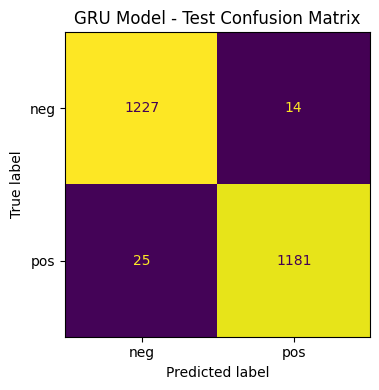

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt

model.load_state_dict(torch.load(GRU_SAVE, map_location=DEVICE))
model.eval()

all_probs, all_preds, all_labels = [], [], []
with torch.no_grad():
    for mel, mfcc, lbl in test_dl:
        out = model(mel.to(DEVICE), mfcc.to(DEVICE))
        all_probs.extend(torch.softmax(out, dim=1)[:,1].cpu().tolist())
        all_preds.extend(out.argmax(1).cpu().tolist())
        all_labels.extend(lbl.tolist())

print('=== Test Set Report ===')
print(classification_report(all_labels, all_preds,
      target_names=['negative','positive'], digits=4))
print(f'ROC-AUC: {roc_auc_score(all_labels, all_probs):.4f}')

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(cm, display_labels=['neg','pos']).plot(ax=ax, colorbar=False)
ax.set_title('GRU Model - Test Confusion Matrix')
plt.tight_layout(); plt.show()


In [ ]:
import onnx

model.load_state_dict(torch.load(GRU_SAVE, map_location='cpu'))
model.eval().cpu()

ONNX_PATH = '/content/siren_gru.onnx'
d_mel  = torch.randn(1, 1, N_MELS,  N_FRAMES)
d_mfcc = torch.randn(1, 1, N_MFCC, N_FRAMES)

with torch.no_grad():
    torch.onnx.export(
        model, (d_mel, d_mfcc), ONNX_PATH,
        input_names=['mel', 'mfcc'], output_names=['logits'],
        opset_version=18,
    )

m = onnx.load(ONNX_PATH)
onnx.checker.check_model(m)
print('ONNX valid')

bad = [n.name for n in m.graph.node if n.op_type == 'Transpose'
       for a in n.attribute if a.name == 'perm' and list(a.ints) == [0,2,1,3]]
print('Transpose(0,2,1,3):', 'NONE - PASS!' if not bad else bad)

[torch.onnx] Obtain model graph for `SirenNetV4_GRU([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SirenNetV4_GRU([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX valid
Transpose(0,2,1,3): NONE - PASS!


In [ ]:
pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 18.8 MB/s eta 0:00:00


In [ ]:
from onnxsim import simplify

ONNX_SIM = '/content/siren_gru_sim.onnx'
m_sim, ok = simplify(m)
if ok:
    onnx.save(m_sim, ONNX_SIM)
    print(f'onnxsim: {ONNX_SIM}')
else:
    print('onnxsim failed - dung file goc')
    ONNX_SIM = ONNX_PATH


Installing onnxruntime by `/usr/bin/python3 -m pip install onnxruntime`, please wait for a moment..

onnxsim: /content/siren_gru_sim.onnx


In [ ]:
import shutil

for src, dst in [
    (GRU_SAVE,  OUT_DIR + '/siren_gru_best.pth'),
    (ONNX_PATH, OUT_DIR + '/siren_gru.onnx'),
    (ONNX_SIM,  OUT_DIR + '/siren_gru_sim.onnx'),
]:
    try:
        shutil.copy(src, dst)
        print(f'Saved: {os.path.basename(dst)} ({os.path.getsize(dst)/1024:.1f} KB)')
    except Exception as e:
        print(f'ERROR: {os.path.basename(dst)}: {e}')

print()
print('Dua vao STM32CubeAI Studio theo thu tu:')
print(f'  1. {OUT_DIR}/siren_gru_sim.onnx  <- Thu truoc')
print(f'  2. {OUT_DIR}/siren_gru.onnx')


Saved: siren_gru_best.pth (15440.6 KB)
Saved: siren_gru.onnx (905.2 KB)
Saved: siren_gru_sim.onnx (15506.1 KB)

Dua vao STM32CubeAI Studio theo thu tu:
  1. /content/drive/MyDrive/siren_gru_output/siren_gru_sim.onnx  <- Thu truoc
  2. /content/drive/MyDrive/siren_gru_output/siren_gru.onnx


In [ ]:
!pip install -U numpy protobuf

!pip install -q onnx onnxsim onnx2tf tensorflow



  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached protobuf-7.34.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
Using cached protobuf-7.34.1-cp310-abi3-manylinux2014_x86_64.whl (324 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.5
    Uninstalling protobuf-4.25.5:
      Successfully uninstalled protobuf-4.25.5
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
onnx2tf 2.4.0 requires numpy==1.26.4, but you have numpy 2.4.4 which is incompatible.
onnx2tf 2.4.0 requires protobuf==4.25.5, but you have protobuf 

^C


In [ ]:
!pip install -q onnx onnxsim onnx2tf tensorflow

!pip install -q 'onnx2tf>=1.20.0'

import tensorflow as tf

import torch

print(f'TF  : {tf.__version__}')

print(f'PyTorch: {torch.__version__}')

In [1]:
!pip install -q onnx onnxsim onnx2tf tensorflow
!pip install -q 'onnx2tf>=1.20.0'
import tensorflow as tf
import torch
print(f'TF  : {tf.__version__}')
print(f'PyTorch: {torch.__version__}')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.2/223.2 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [2]:
!pip install -U numpy==1.26.4 protobuf==4.25.3
!pip install onnx onnxsim onnx2tf tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 11.8 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.5
    Uninstalling protobuf-4.25.5:
      Successfully uninstalled protobuf-4.25.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
onnx2tf 2.4.0 requires protobuf==4.25.5, but you have protobuf 4.25.3 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.3 which is incompatible.
google-cloud-trace 1.19.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
google-cloud-language 2.20.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
proto-plus 1.27.2 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you h

  Using cached protobuf-4.25.5-cp37-abi3-manylinux2014_x86_64.whl.metadata (541 bytes)
Using cached protobuf-4.25.5-cp37-abi3-manylinux2014_x86_64.whl (294 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.3
    Uninstalling protobuf-4.25.3:
      Successfully uninstalled protobuf-4.25.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.5 which is incompatible.
google-cloud-trace 1.19.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.5 which is incompatible.
google-cloud-language 2.20.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.5 which is incompatible.
proto-plus 1.27.2 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.5 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4

In [1]:
import numpy as np
import tensorflow as tf
import torch

print(f'NumPy  : {np.__version__}')
print(f'TF     : {tf.__version__}')
print(f'PyTorch: {torch.__version__}')

NumPy  : 1.26.4
TF     : 2.19.0
PyTorch: 2.10.0+cpu


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, torch

WEIGHT_PATH = '/content/drive/MyDrive/siren_gru_output/siren_gru_best.pth'
DATASET_ZIP = '/content/drive/MyDrive/dataset.zip'
OUT_DIR     = '/content/drive/MyDrive/siren_gru_output'

SR         = 22050
N_MELS     = 64
N_MFCC     = 40
HOP_LEN    = 512
N_FFT      = 1024
FMIN       = 300
FMAX       = 3500
CLIP_SEC   = 2.0
CLIP_LEN   = int(CLIP_SEC * SR)
STRIDE_SEC = 0.17
PRE_EMPH   = 0.97
MEL_FREQ_AFTER_POOL  = N_MELS // 4
MFCC_FREQ_AFTER_POOL = N_MFCC // 4
N_FRAMES   = CLIP_LEN // HOP_LEN + 1
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Input mel : (1, 1, {N_MELS}, {N_FRAMES})')
print(f'Input mfcc: (1, 1, {N_MFCC}, {N_FRAMES})')


Mounted at /content/drive
Input mel : (1, 1, 64, 87)
Input mfcc: (1, 1, 40, 87)


In [3]:
import torch.nn as nn
import torch.nn.functional as F

class CNNBranch(nn.Module):
    def __init__(self, in_ch=1, base=32, freq_after_pool=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, base,    3, padding=1, bias=False), nn.BatchNorm2d(base),   nn.GELU(),
            nn.Conv2d(base,   base,   3, padding=1, bias=False), nn.BatchNorm2d(base),   nn.GELU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.1),
            nn.Conv2d(base,   base*2, 3, padding=1, bias=False), nn.BatchNorm2d(base*2), nn.GELU(),
            nn.Conv2d(base*2, base*2, 3, padding=1, bias=False), nn.BatchNorm2d(base*2), nn.GELU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.15),
            nn.Conv2d(base*2, base*4, 3, padding=1, bias=False), nn.BatchNorm2d(base*4), nn.GELU(),
            nn.Conv2d(base*4, base*4, 3, padding=1, bias=False), nn.BatchNorm2d(base*4), nn.GELU(),
            nn.Dropout2d(0.2),
        )
        self.freq_pool = nn.AvgPool2d(kernel_size=(freq_after_pool, 1))
    def forward(self, x):
        h = self.net(x)
        h = self.freq_pool(h)
        return h.squeeze(2).permute(0, 2, 1)

class ManualGRUCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.H  = hidden_size
        self.ih = nn.Linear(input_size,  hidden_size * 3)
        self.hh = nn.Linear(hidden_size, hidden_size * 3)
    def forward(self, x, h):
        gi = self.ih(x); gh = self.hh(h); H = self.H
        r = torch.sigmoid(gi[:, :H]    + gh[:, :H])
        z = torch.sigmoid(gi[:, H:2*H] + gh[:, H:2*H])
        n = torch.tanh(   gi[:, 2*H:]  + r * gh[:, 2*H:])
        return (1 - z) * n + z * h

class ManualGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=2, dropout=0.3):
        super().__init__()
        self.H = hidden_size; self.L = num_layers; self.dropout_p = dropout
        self.cells = nn.ModuleList([
            ManualGRUCell(input_size if i == 0 else hidden_size, hidden_size)
            for i in range(num_layers)
        ])
    def forward(self, x):
        B, T, _ = x.shape
        h = [torch.zeros(B, self.H, device=x.device, dtype=x.dtype) for _ in range(self.L)]
        outputs = []
        for t in range(T):
            inp = x[:, t, :]
            for i, cell in enumerate(self.cells):
                h[i] = cell(inp, h[i]); inp = h[i]
                if self.training and self.dropout_p > 0 and i < self.L - 1:
                    inp = F.dropout(inp, p=self.dropout_p)
            outputs.append(inp)
        return torch.stack(outputs, dim=1)

class SirenNetV4_GRU(nn.Module):
    def __init__(self, n_classes=2, base_ch=48, gru_hidden=512, gru_layers=2):
        super().__init__()
        self.mel_cnn  = CNNBranch(1, base_ch,      MEL_FREQ_AFTER_POOL)
        self.mfcc_cnn = CNNBranch(1, base_ch // 2, MFCC_FREQ_AFTER_POOL)
        total_ch = base_ch * 4 + (base_ch // 2) * 4
        self.gru = ManualGRU(total_ch, gru_hidden, gru_layers, dropout=0.3)
        self.attn_w = nn.Linear(gru_hidden, 1)
        self.classifier = nn.Sequential(
            nn.Linear(gru_hidden, 512), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(512, 128),        nn.GELU(), nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )
    def forward(self, mel, mfcc):
        mel_f  = self.mel_cnn(mel)
        mfcc_f = self.mfcc_cnn(mfcc)
        x = torch.cat([mel_f, mfcc_f], dim=-1)
        gru_out = self.gru(x)
        a   = torch.softmax(self.attn_w(gru_out), dim=1)
        ctx = (gru_out * a).sum(dim=1)
        return self.classifier(ctx)

model = SirenNetV4_GRU().to(DEVICE)
model.load_state_dict(torch.load(WEIGHT_PATH, map_location=DEVICE))
model.eval()
print('Model loaded OK')
print(f'Params: {sum(p.numel() for p in model.parameters()):,}')


Model loaded OK
Params: 3,943,083


In [4]:
import onnx

ONNX_PATH = '/content/siren_gru_fp32.onnx'
model.eval().cpu()
d_mel  = torch.randn(1, 1, N_MELS,  N_FRAMES)
d_mfcc = torch.randn(1, 1, N_MFCC, N_FRAMES)

with torch.no_grad():
    torch.onnx.export(
        model, (d_mel, d_mfcc), ONNX_PATH,
        input_names=['mel', 'mfcc'],
        output_names=['logits'],
        opset_version=18,
    )

m = onnx.load(ONNX_PATH)
onnx.checker.check_model(m)
size_mb = os.path.getsize(ONNX_PATH) / 1024 / 1024
print(f'ONNX FP32: {size_mb:.2f} MB')


[torch.onnx] Obtain model graph for `SirenNetV4_GRU([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SirenNetV4_GRU([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 24 of general pattern rewrite rules.
ONNX FP32: 0.89 MB


In [17]:
# 1. Chuyển đổi từ ONNX sang TensorFlow SavedModel
!onnx2tf \
    -i /content/siren_gru_fp32.onnx \
    -o /content/saved_model \
    -tb tf_converter \
    -n

import tensorflow as tf
import os

# 2. Kiểm tra và load
# onnx2tf thường xuất ra folder /content/saved_model trực tiếp
model_path = '/content/saved_model'

print("Các file trong folder output:")
if os.path.exists(model_path):
    print(os.listdir(model_path))

try:
    loaded = tf.saved_model.load(model_path)
    print('✅ SavedModel loaded OK')
except Exception as e:
    print(f'❌ Lỗi load model: {e}')

Saved artifact at '/content/saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 64, 87, 1), dtype=tf.float32, name='mel')
  inputs_1 (POSITIONAL_ONLY): TensorSpec(shape=(1, 40, 87, 1), dtype=tf.float32, name='mfcc')
Output Type:
  TensorSpec(shape=(1, 2), dtype=tf.float32, name=None)
W0000 00:00:1776926688.913890    6121 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1776926688.916804    6121 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1776926689.581458    6121 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
W0000 00:00:1776927111.078815    6121 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1776927111.081273    6121 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
Các file trong folder output:
['assets', 'variables', 'saved_model.pb', 'fingerprint.pb', 'siren_gru_fp32_float32.tfl

In [7]:
!ls -R /content/saved_model

/content/saved_model:
schema.fbs		       siren_gru_fp32_float32.tflite
schema_generated.py	       siren_gru_fp32_tensor_correspondence_report.json
siren_gru_fp32_float16.tflite


In [8]:
!rm -rf /content/saved_model

In [12]:
pwd

'/content'

In [13]:
ls

drive/        saved_model/         siren_gru_fp32.onnx.data
sample_data/  siren_gru_fp32.onnx


In [14]:
rm -r saved_model/

In [18]:
import tensorflow as tf
# Kiểm tra SavedModel load được
loaded = tf.saved_model.load('/content/saved_model')
print('SavedModel loaded OK')

SavedModel loaded OK


In [20]:
import zipfile, os, numpy as np, librosa, random
from pathlib import Path

# 1. Giải nén và kiểm tra thư mục
DATASET_ZIP = '/content/drive/MyDrive/dataset.zip' # Kiểm tra lại đường dẫn này trên Drive của bạn
EXTRACT_DIR = '/content/dataset_tmp'

if not os.path.exists(EXTRACT_DIR):
    print(' đang giải nén...')
    with zipfile.ZipFile(DATASET_ZIP) as z:
        z.extractall(EXTRACT_DIR)

root_path = EXTRACT_DIR
for root, dirs, files in os.walk(EXTRACT_DIR):
    if 'positive' in dirs or 'negative' in dirs:
        root_path = root
        break

print(f"✅ Đã tìm thấy dữ liệu tại: {root_path}")

# 2. Lấy file wav
random.seed(42)
wav_files = []
for folder in ['positive', 'negative', 'Positive', 'Negative']: # Thêm cả chữ hoa cho chắc
    fp = Path(root_path) / folder
    if fp.exists():
        # Tìm tất cả file .wav, .WAV, .mp3...
        found = list(fp.glob('**/*.wav')) + list(fp.glob('**/*.WAV'))
        print(f" - Thư mục {folder}: tìm thấy {len(found)} file")
        wav_files += random.sample(found, min(100, len(found)))

print(f'🚀 Tổng số file dùng để Calibration: {len(wav_files)}')

if len(wav_files) == 0:
    print("❌ LỖI: Không tìm thấy file .wav nào! Hãy kiểm tra lại file zip hoặc cấu trúc folder.")
else:
    calib_mel, calib_mfcc = [], []
    errors = 0
    for wp in wav_files:
        try:
            m, mc = wav_to_inputs(str(wp))
            calib_mel.append(m)
            calib_mfcc.append(mc)
        except Exception as e:
            errors += 1

    if len(calib_mel) > 0:
        calib_mel  = np.concatenate(calib_mel,  axis=0).astype(np.float32)
        calib_mfcc = np.concatenate(calib_mfcc, axis=0).astype(np.float32)
        print(f'✔ Calib mel : {calib_mel.shape}')
        print(f'✔ Calib mfcc: {calib_mfcc.shape}')
    if errors: print(f'⚠ Số file lỗi: {errors}')

 đang giải nén...
✅ Đã tìm thấy dữ liệu tại: /content/dataset_tmp/clips
 - Thư mục positive: tìm thấy 8039 file
 - Thư mục negative: tìm thấy 8273 file
🚀 Tổng số file dùng để Calibration: 200
✔ Calib mel : (200, 1, 64, 87)
✔ Calib mfcc: (200, 1, 40, 87)


In [28]:
import zipfile, numpy as np, librosa
from pathlib import Path
from scipy.signal import butter, sosfilt

OLD_DIR = '/content/dataset'
if not os.path.exists(OLD_DIR):
    print('Giải nén...')
    with zipfile.ZipFile(DATASET_ZIP) as z: z.extractall('/content')

def pre_emphasis(y, c=0.97): return np.append(y[0], y[1:] - c * y[:-1])
def bandpass(y, sr):
    sos = butter(4, [500, 1800], btype='band', fs=sr, output='sos')
    return sosfilt(sos, y)
def normalize(x): return (x - x.mean()) / (x.std() + 1e-6)
def fix_len(x, T): return x[:, :T] if x.shape[1] >= T else np.pad(x, ((0,0),(0,T-x.shape[1])))

def wav_to_inputs(wav_path):
    y, sr = librosa.load(wav_path, sr=SR, mono=True)
    y = bandpass(y, sr)
    if len(y) < CLIP_LEN:
        pad = np.zeros(CLIP_LEN); pad[:len(y)] = y; y = pad
    seg = y[:CLIP_LEN]
    mel = normalize(librosa.power_to_db(
        librosa.feature.melspectrogram(y=pre_emphasis(seg), sr=SR,
            n_fft=N_FFT, hop_length=HOP_LEN, n_mels=N_MELS, fmin=FMIN, fmax=FMAX),
        ref=np.max)).astype(np.float32)
    mfcc = normalize(librosa.feature.mfcc(y=pre_emphasis(seg), sr=SR,
        n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LEN, fmin=FMIN, fmax=FMAX
    ).astype(np.float32))
    return fix_len(mel, N_FRAMES)[np.newaxis, np.newaxis], fix_len(mfcc, N_FRAMES)[np.newaxis, np.newaxis]

# Lấy tối đa 100 file mỗi class
import random
random.seed(42)
wav_files = []
for folder in ['positive', 'negative']:
    fp = Path(OLD_DIR) / folder
    if fp.exists():
        wavs = list(fp.glob('*.wav')) + list(fp.glob('*.WAV'))
        wav_files += random.sample(wavs, min(100, len(wavs)))

print(f'Calibration files: {len(wav_files)}')

# Extract features
calib_mel, calib_mfcc = [], []
errors = 0
for wp in wav_files:
    try:
        m, mc = wav_to_inputs(str(wp))
        calib_mel.append(m); calib_mfcc.append(mc)
    except: errors += 1

calib_mel  = np.concatenate(calib_mel,  axis=0).astype(np.float32)
calib_mfcc = np.concatenate(calib_mfcc, axis=0).astype(np.float32)
print(f'Calib mel : {calib_mel.shape}')
print(f'Calib mfcc: {calib_mfcc.shape}')
if errors: print(f'Errors: {errors}')


Calibration files: 200
Calib mel : (200, 1, 64, 87)
Calib mfcc: (200, 1, 40, 87)


In [22]:
rm -r dataset_tmp

In [23]:
cp drive/MyDrive/dataset.zip .

In [27]:
import zipfile
zipfile.ZipFile('dataset.zip').extractall('/content')

In [29]:
import tensorflow as tf
import numpy as np

TFLITE_FP32_PATH = '/content/siren_gru_fp32.tflite'
TFLITE_INT8_PATH = '/content/siren_gru_int8.tflite'

converter = tf.lite.TFLiteConverter.from_saved_model('/content/saved_model')

# ── Bước 1: Export FP32 TFLite trước để so sánh size ──────────────────────
tflite_fp32 = converter.convert()
with open(TFLITE_FP32_PATH, 'wb') as f: f.write(tflite_fp32)
fp32_kb = os.path.getsize(TFLITE_FP32_PATH) / 1024
print(f'TFLite FP32: {fp32_kb:.1f} KB')

# ── Bước 2: Full INT8 Quantization ────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_saved_model('/content/saved_model')
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8

# Representative dataset — calibrate activation range với data thật
def representative_dataset():
    for i in range(len(calib_mel)):
        yield [
            calib_mel[i:i+1],   # mel input
            calib_mfcc[i:i+1],  # mfcc input
        ]

converter.representative_dataset = representative_dataset

tflite_int8 = converter.convert()
with open(TFLITE_INT8_PATH, 'wb') as f: f.write(tflite_int8)
int8_kb = os.path.getsize(TFLITE_INT8_PATH) / 1024

print(f'TFLite INT8: {int8_kb:.1f} KB')
print(f'Compression: {fp32_kb/int8_kb:.1f}x smaller')


ConverterError: Could not translate MLIR to FlatBuffer.<unknown>:0: error: loc(callsite(callsite(fused["Erf:", "model_10/tf.math.erf_1/Erf@__inference_<lambda>_47216"] at fused["PartitionedCall:", "PartitionedCall@__inference_signature_wrapper_<lambda>_48917"]) at fused["PartitionedCall:", "PartitionedCall"])): 'tf.Erf' op is neither a custom op nor a flex op
<unknown>:0: note: loc(fused["PartitionedCall:", "PartitionedCall"]): called from
<unknown>:0: note: loc(callsite(callsite(fused["Erf:", "model_10/tf.math.erf_1/Erf@__inference_<lambda>_47216"] at fused["PartitionedCall:", "PartitionedCall@__inference_signature_wrapper_<lambda>_48917"]) at fused["PartitionedCall:", "PartitionedCall"])): see current operation: %86 = "tf.Erf"(%85) {device = ""} : (tensor<1x40x87x24xf32>) -> tensor<1x40x87x24xf32>
<unknown>:0: note: loc(callsite(callsite(fused["Erf:", "model_10/tf.math.erf_1/Erf@__inference_<lambda>_47216"] at fused["PartitionedCall:", "PartitionedCall@__inference_signature_wrapper_<